# Analisis de conectividad del subte de CABA

Este notebook cubre el ejercicio 1 del trabajo practico y busca responder dos preguntas de forma clara e intuitiva:

1. Como esta organizada la red de subte y donde se concentran los transbordos.
2. Que estaciones ocupan posiciones mas centrales y cuales quedan mas perifericas cuando se pondera el tiempo de viaje.

Las visualizaciones se simplificaron para evitar saturacion: se etiquetan solo estaciones clave, se distinguen los transbordos con linea punteada y las metricas se muestran con una breve interpretacion. Los ejercicios 2 y 3 quedan continuados en `analisis_mercado_y_atraccion_subte_caba.ipynb`.

In [1]:
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

from analisis_conectividad_subte_caba import generate_outputs

BASE_DIR = Path.cwd()
FIGURES_DIR = BASE_DIR / 'figures'
OUTPUT_DIR = BASE_DIR / 'outputs'

results = generate_outputs()
checks = results['checks']
stats = results['stats']
summary = results['summary']
line_summary = results['line_summary']
top_central = results['top_central']
top_peripheral = results['top_peripheral']
future = results['future']

## 1. Verificacion de consistencia

Antes de interpretar la red, conviene validar que el modelo este bien construido.
Los chequeos de abajo confirman que:

- las 89 estaciones aparecen en el grafo,
- no faltan posiciones geograficas ni esquematicas,
- todas las estaciones estan conectadas al resto de la red.

In [2]:
pd.DataFrame(
    {
        'indicador': list(checks.keys()) + list(stats.keys()),
        'valor': list(checks.values()) + list(stats.values()),
    }
)

,indicador,valor
0,estaciones,90
1,conexiones,98
2,nodos_grafo,90
3,grafo_conexo,True
4,ids_sin_conexion,0
5,ids_sin_pos_geo,0
6,ids_sin_pos_diag,0
7,nodos,90
8,aristas,98
9,transbordos,14


## 2. Estructura general de la red

La vista geografica ayuda a ubicar la red en la ciudad. La vista esquematica, en cambio, facilita leer la topologia: donde se cruzan lineas, donde aparecen los corredores mas largos y como se distribuyen los transbordos.

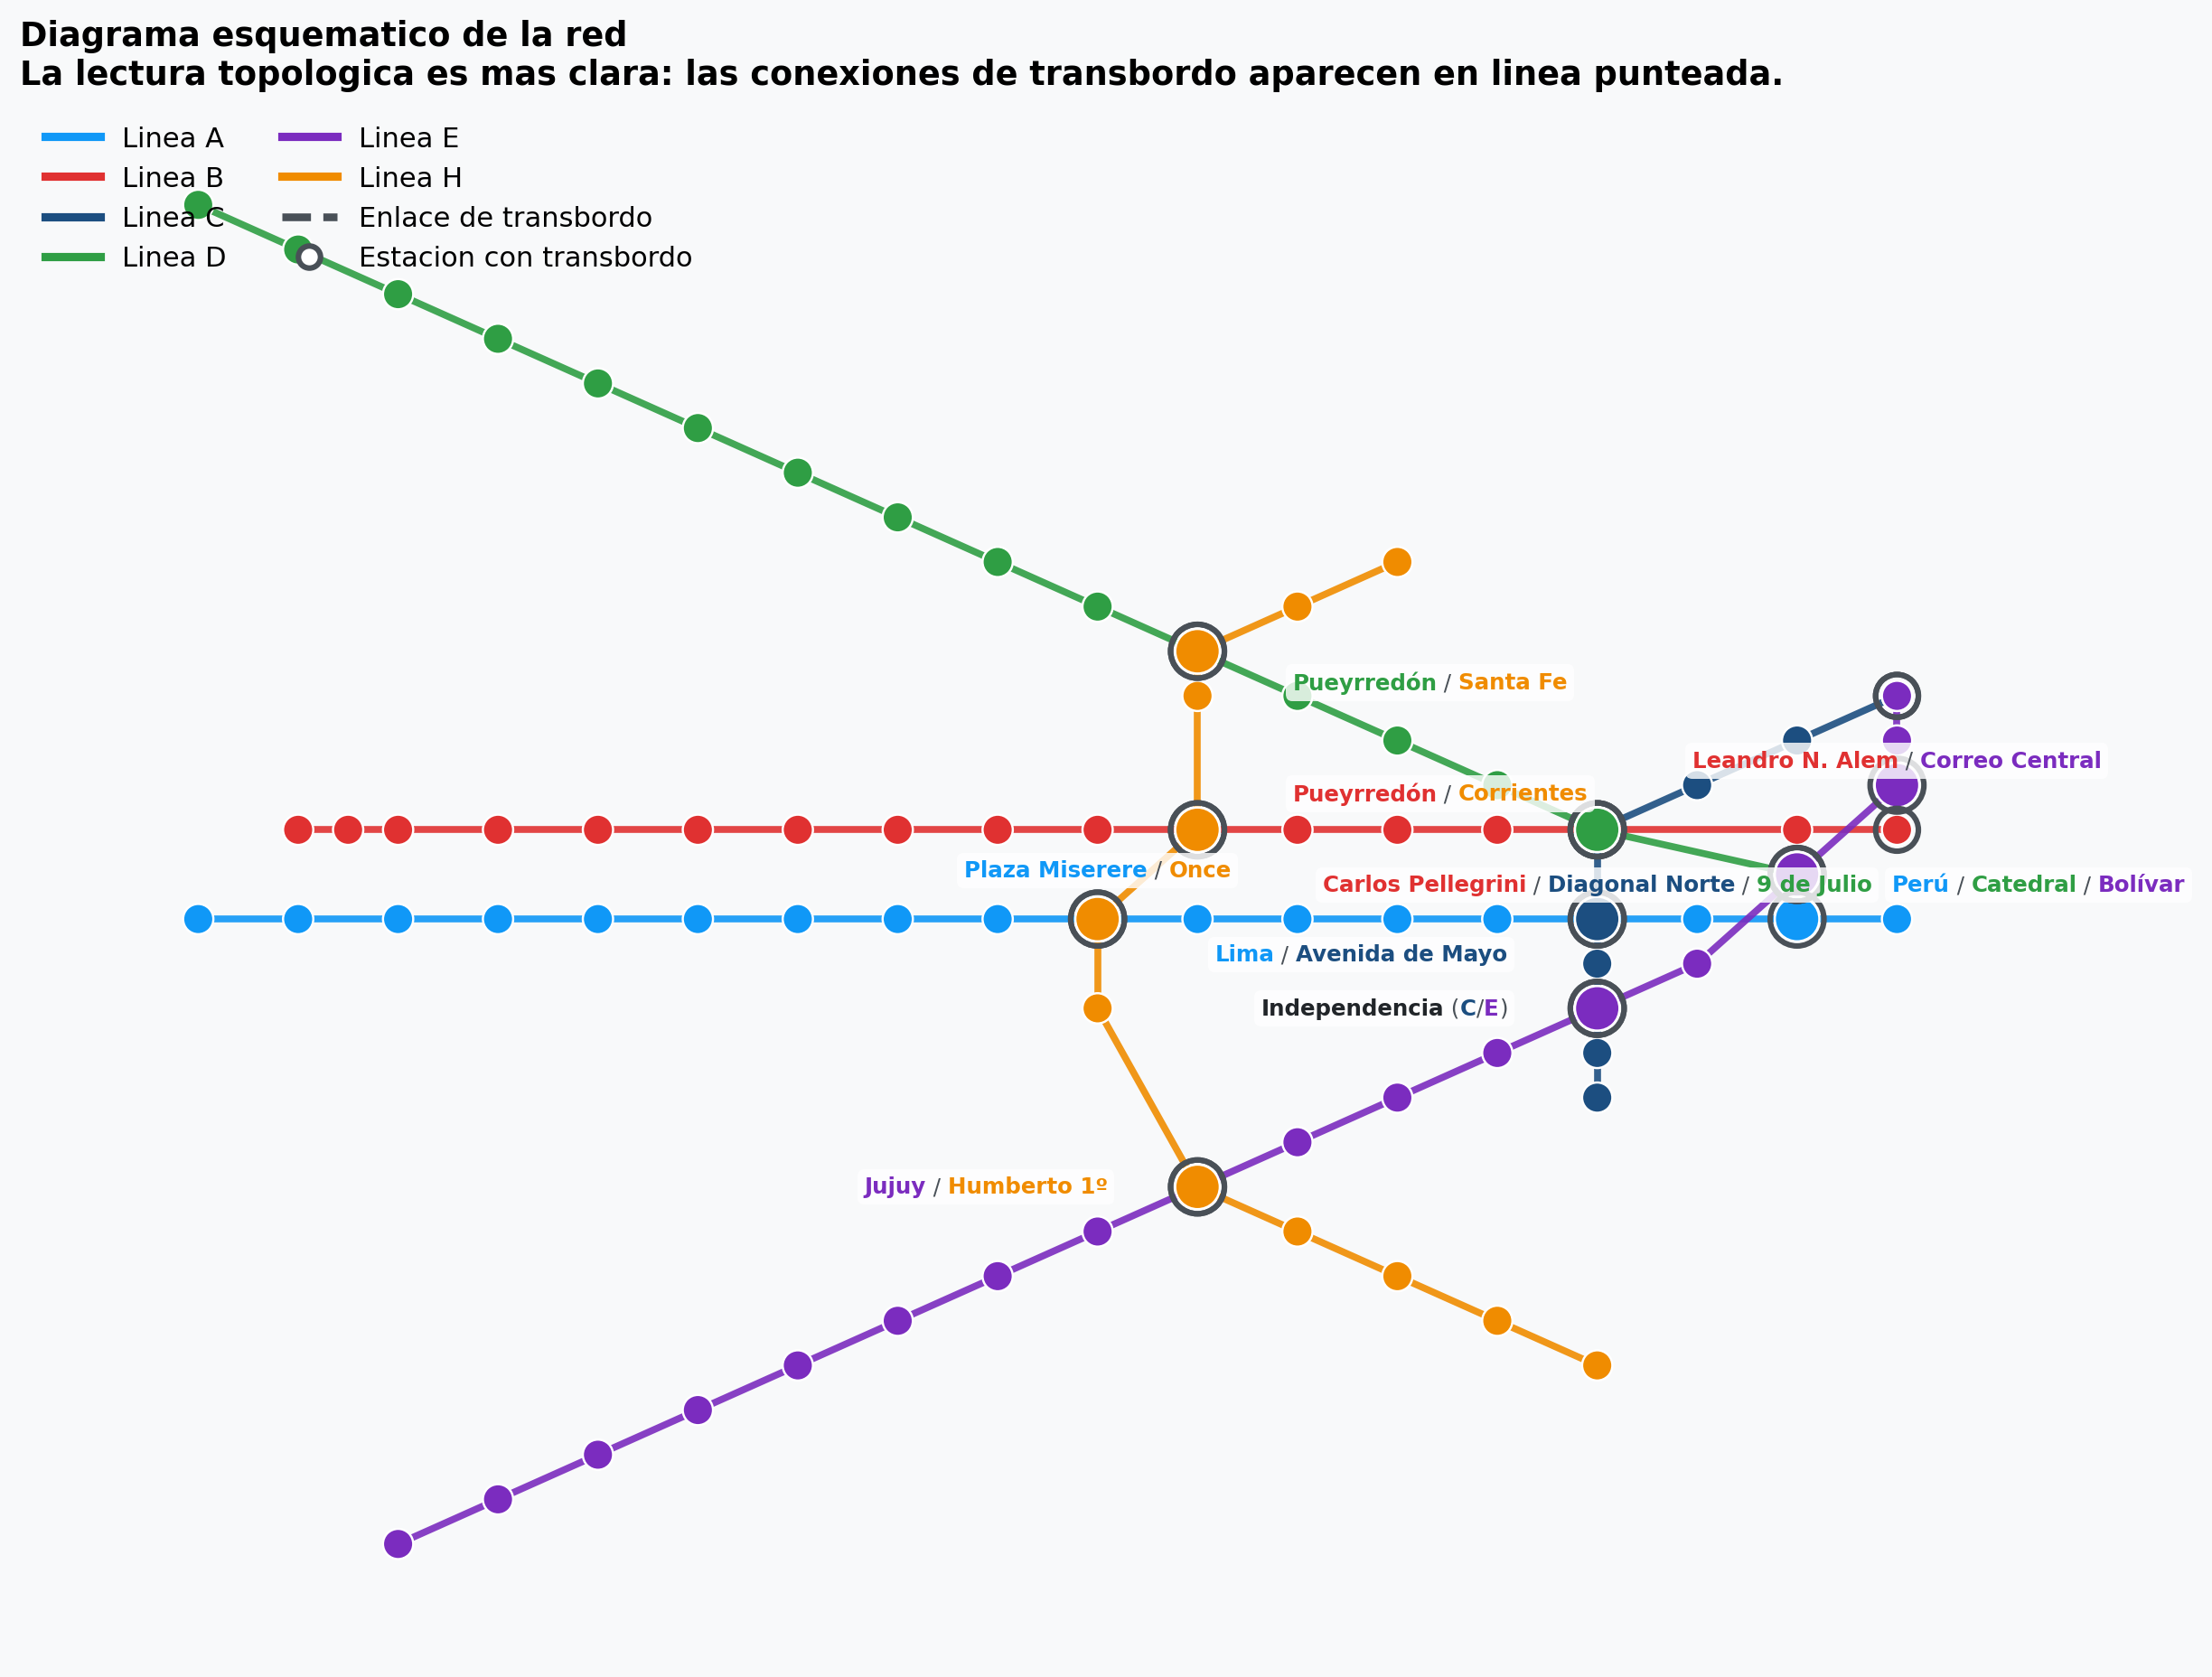

In [3]:
display(Image(filename=str(FIGURES_DIR / 'red_subte_caba_mapa_geografico.png')))
display(Image(filename=str(FIGURES_DIR / 'red_subte_caba_mapa_esquematico.png')))

Lectura rapida:

- Las lineas A, B, D y E concentran buena parte de la estructura longitudinal.
- Los transbordos se agrupan sobre todo en el area central.
- La linea H funciona como un conector transversal clave entre varios corredores radiales.

## 3. Estaciones mas centrales

Se usan metricas ponderadas por tiempo de viaje. Dos de las mas utiles para interpretar la red son:

- **Betweenness**: mide cuanto actua una estacion como puente en rutas minimas.
- **Closeness**: mide que tan rapido se llega desde una estacion al resto de la red.

En los mapas siguientes, los nodos mas grandes y oscuros concentran valores mas altos.

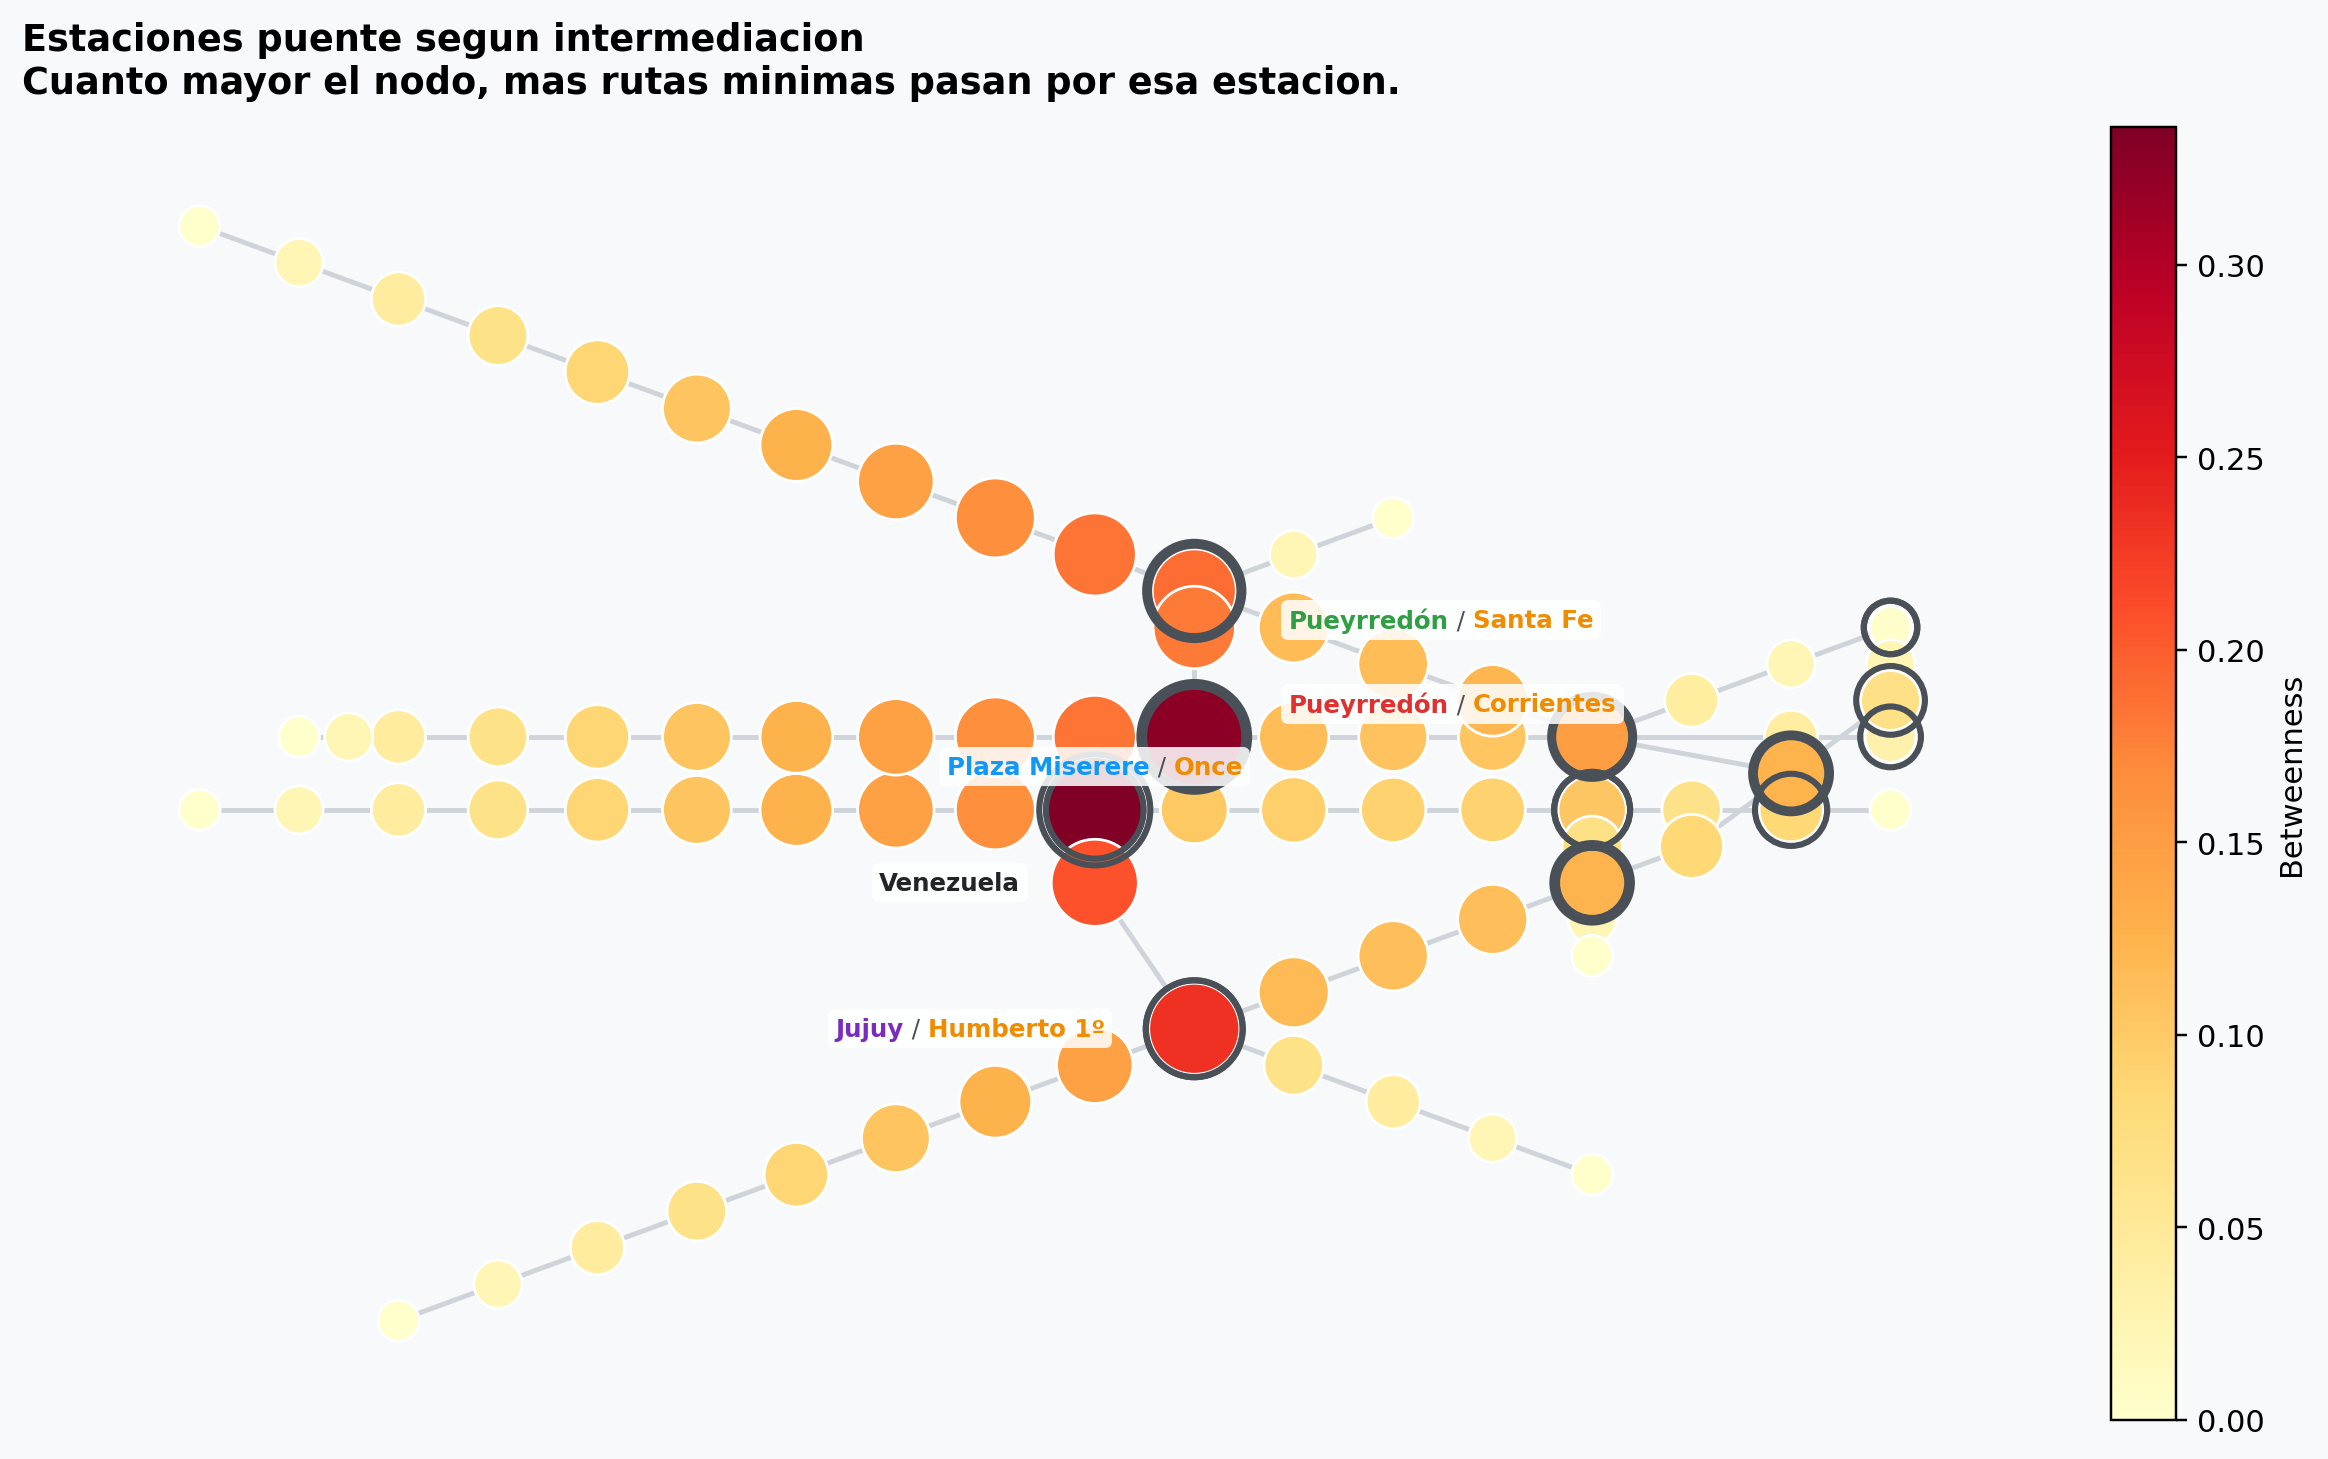

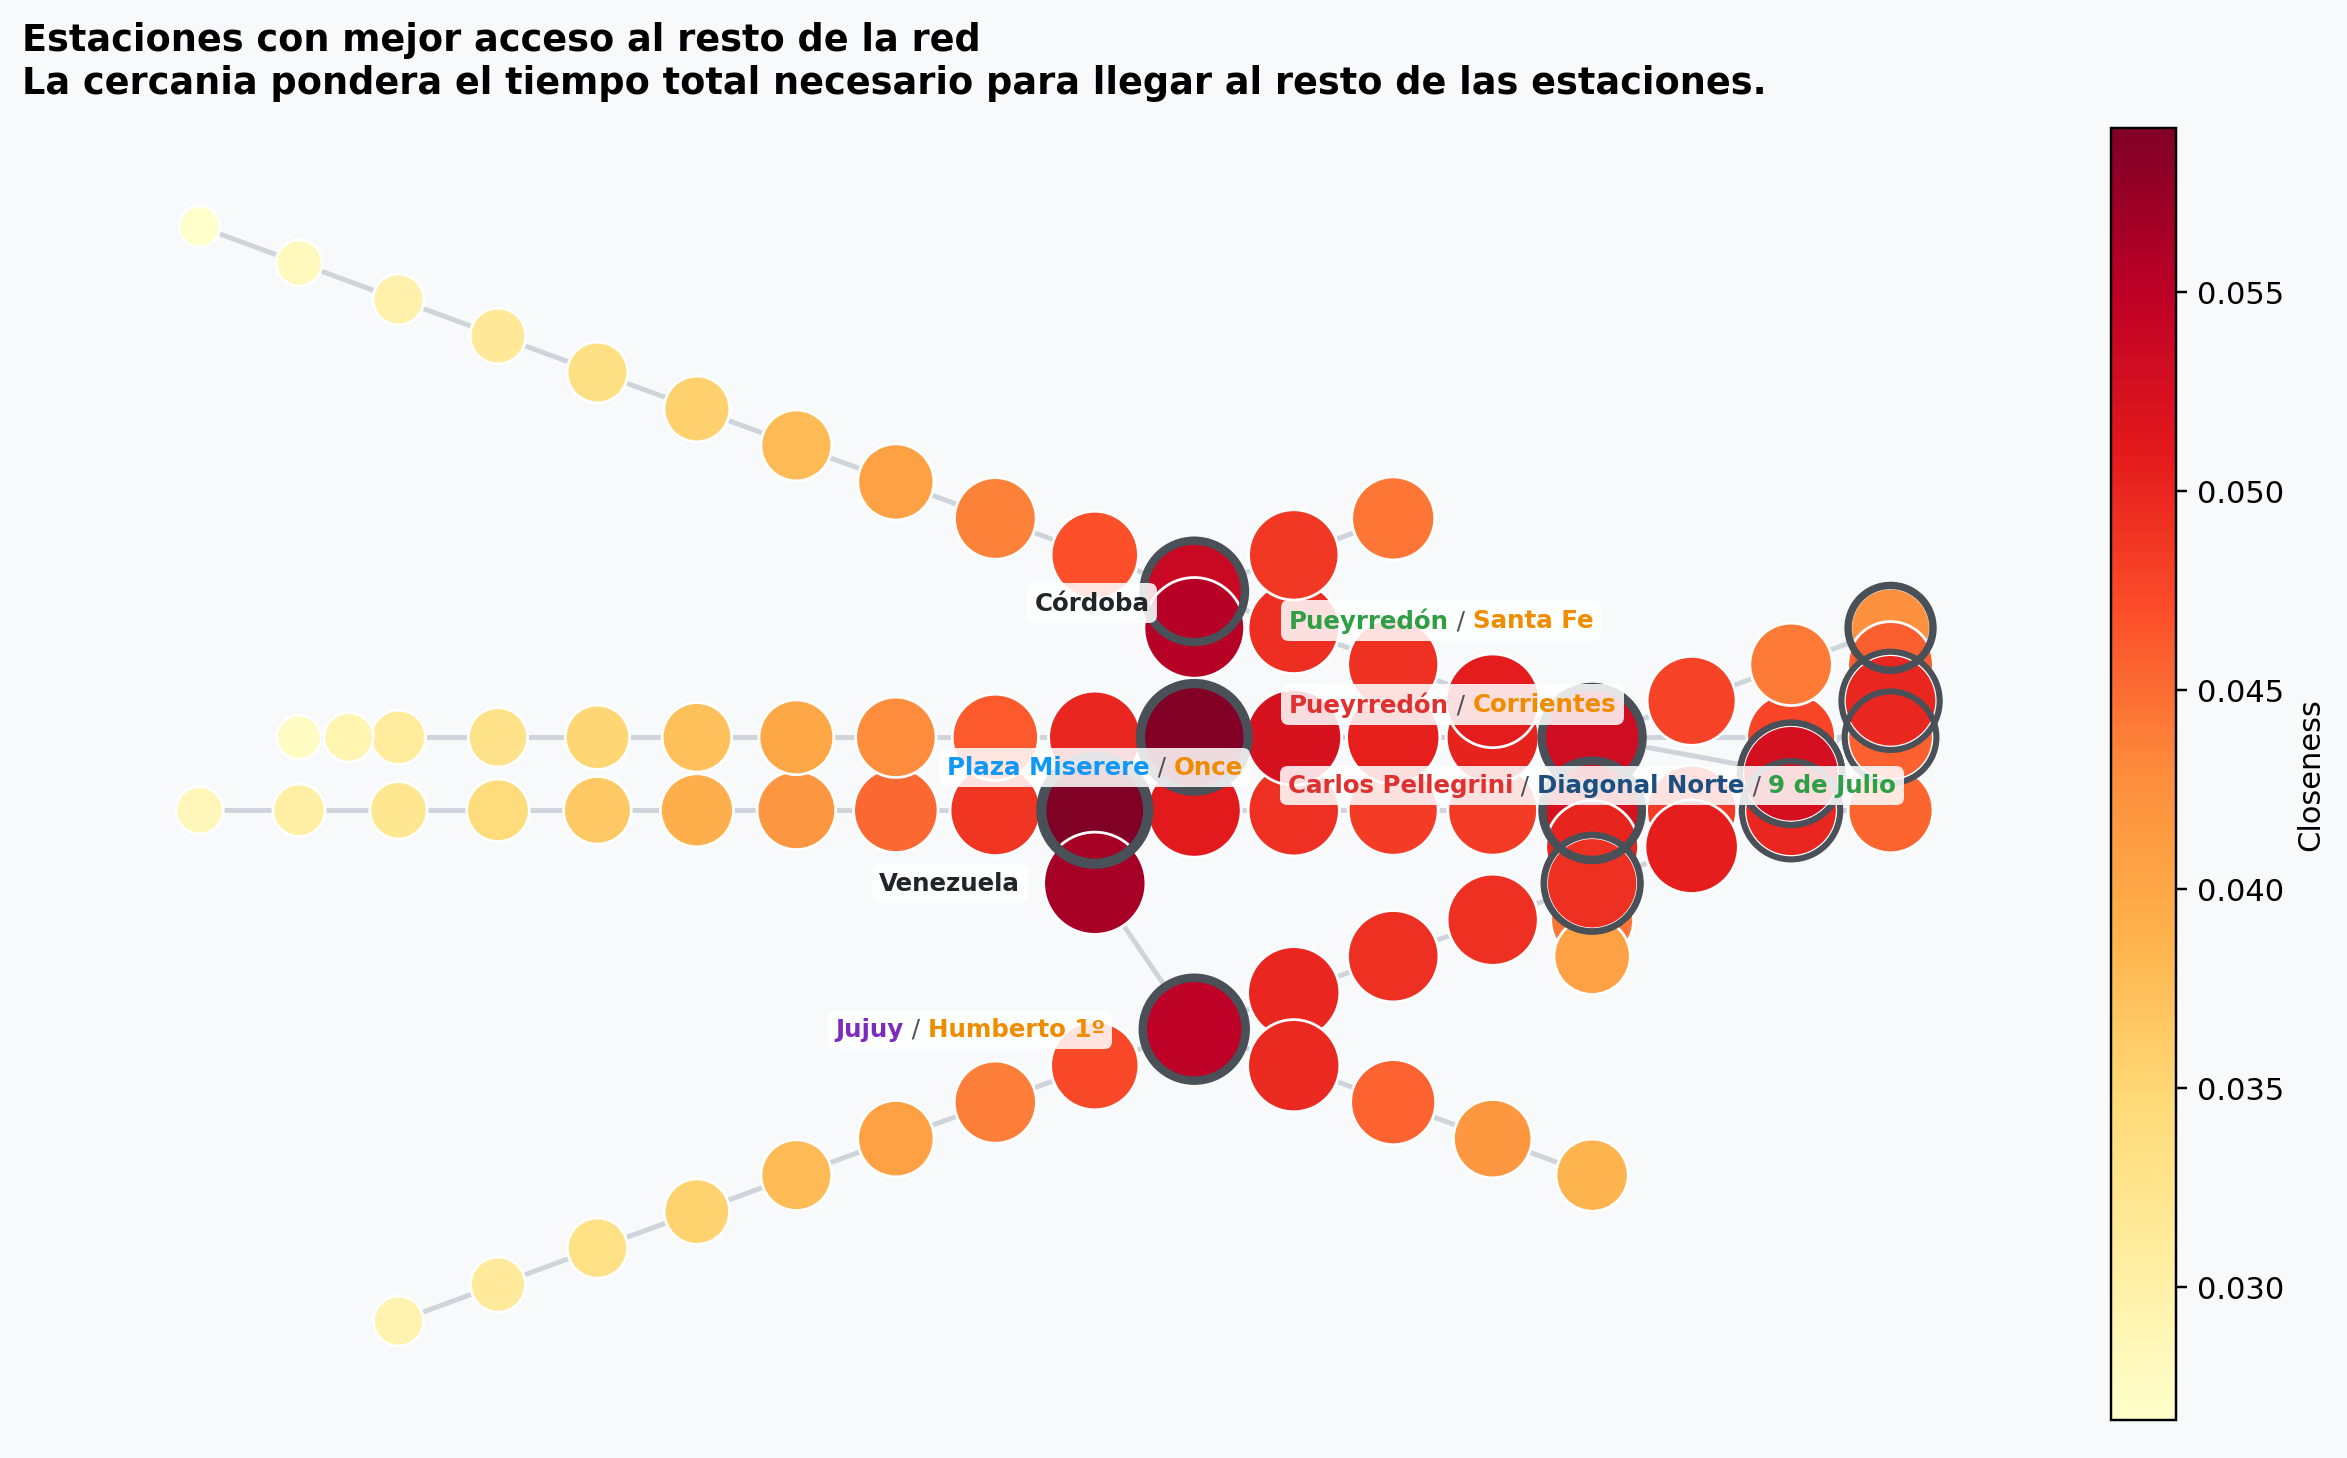

In [4]:
display(Image(filename=str(FIGURES_DIR / 'centralidad_estaciones_por_intermediacion.png')))
display(Image(filename=str(FIGURES_DIR / 'centralidad_estaciones_por_cercania.png')))

El ranking agregado combina grado, intermediacion, cercania, autovector y baja excentricidad. Un score menor implica una posicion mas central dentro de la red.

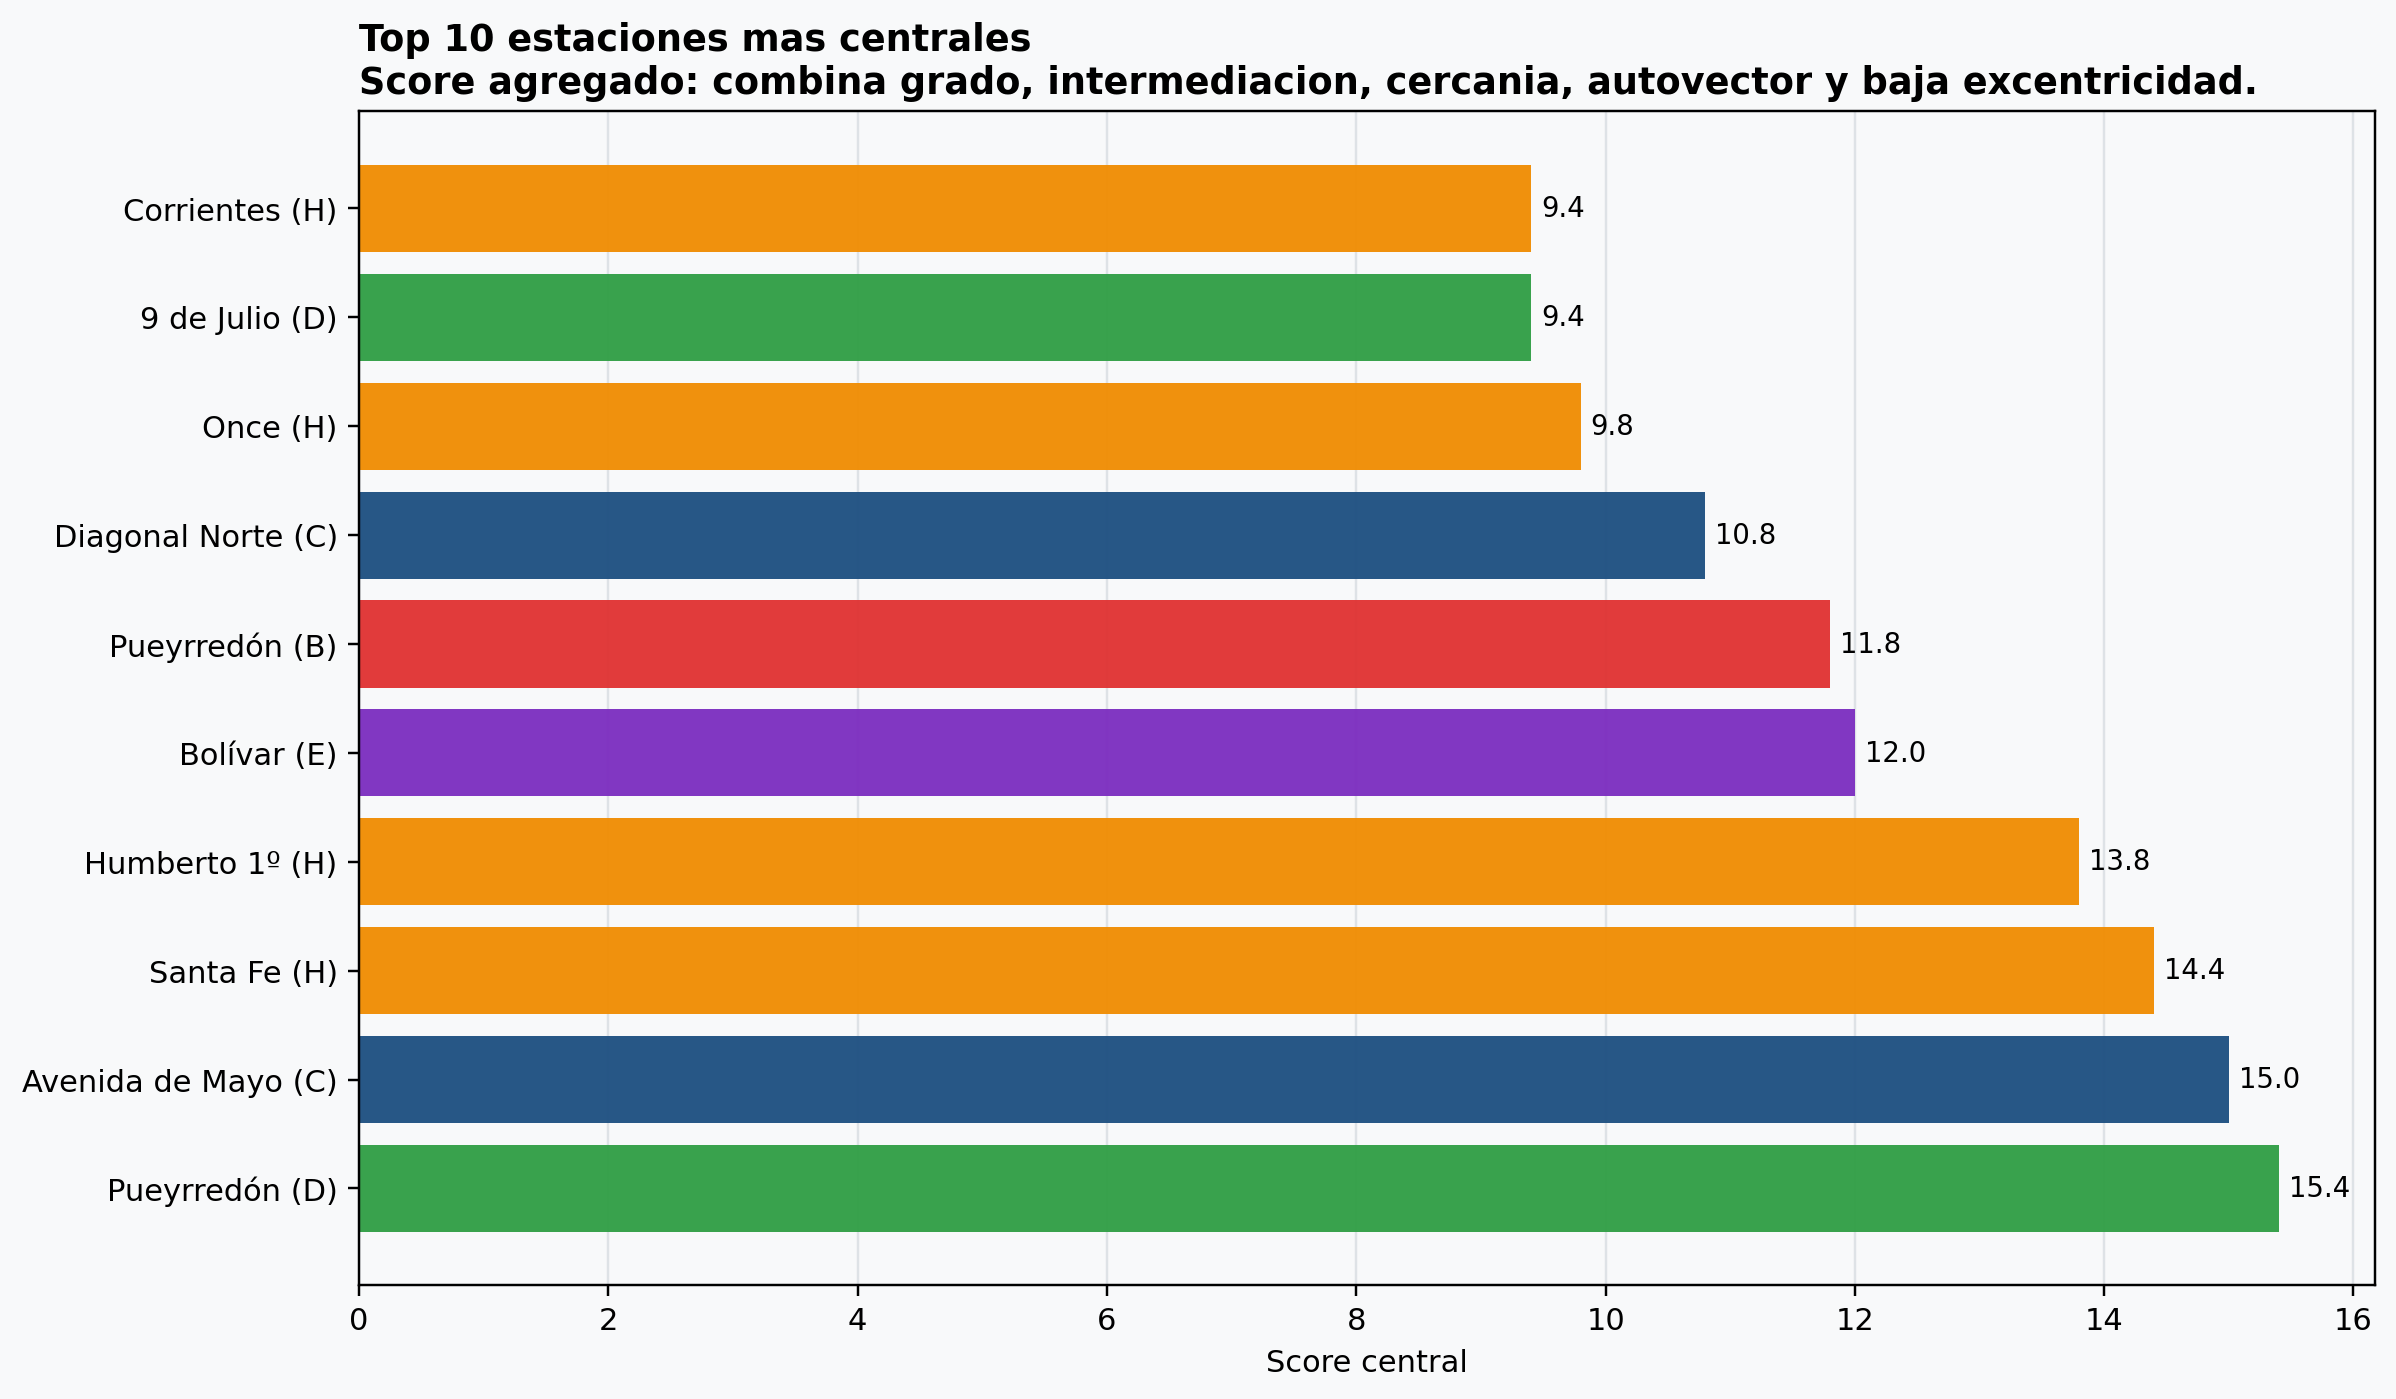

,estacion,linea,grado,betweenness,closeness,autovector,excentricidad,score_central,score_periferico
82,Corrientes,H,3.0,0.325375,0.058901,0.068405,31,9.4,78.8
45,9 de Julio,D,4.0,0.149174,0.053293,0.240144,39,9.4,80.2
83,Once,H,3.0,0.335717,0.059136,0.067409,33,9.8,78.4
38,Diagonal Norte,C,4.0,0.116233,0.052384,0.259318,36,10.8,79.2
24,Pueyrredón,B,3.0,0.254980,0.054268,0.067472,36,11.8,76.4
60,Bolívar,E,4.0,0.125255,0.052632,0.277798,40,12.0,76.8
85,Humberto 1º,H,3.0,0.232763,0.054904,0.057233,37,13.8,74.6
80,Santa Fe,H,3.0,0.189351,0.053744,0.045907,31,14.4,73.8
39,Avenida de Mayo,C,3.0,0.104869,0.052353,0.252596,38,15.0,72.2
49,Pueyrredón,D,3.0,0.240935,0.050655,0.065683,38,15.4,71.6


In [5]:
display(Image(filename=str(FIGURES_DIR / 'ranking_estaciones_centrales.png')))
top_central

Interpretacion:

- **Corrientes** y **Once** aparecen arriba porque conectan varios recorridos y quedan bien posicionadas para redistribuir viajes.
- **9 de Julio**, **Bolivar** y **Diagonal Norte** combinan mucha conectividad con ubicacion central.
- La presencia repetida de estaciones de la linea H confirma su rol articulador en la red actual.

## 4. Estaciones mas perifericas

La excentricidad captura cuan lejos queda cada estacion de su punto mas lejano dentro de la red. Para la periferia conviene mirar dos cosas juntas:

- valores altos de excentricidad,
- scores agregados que reflejen baja conectividad relativa.

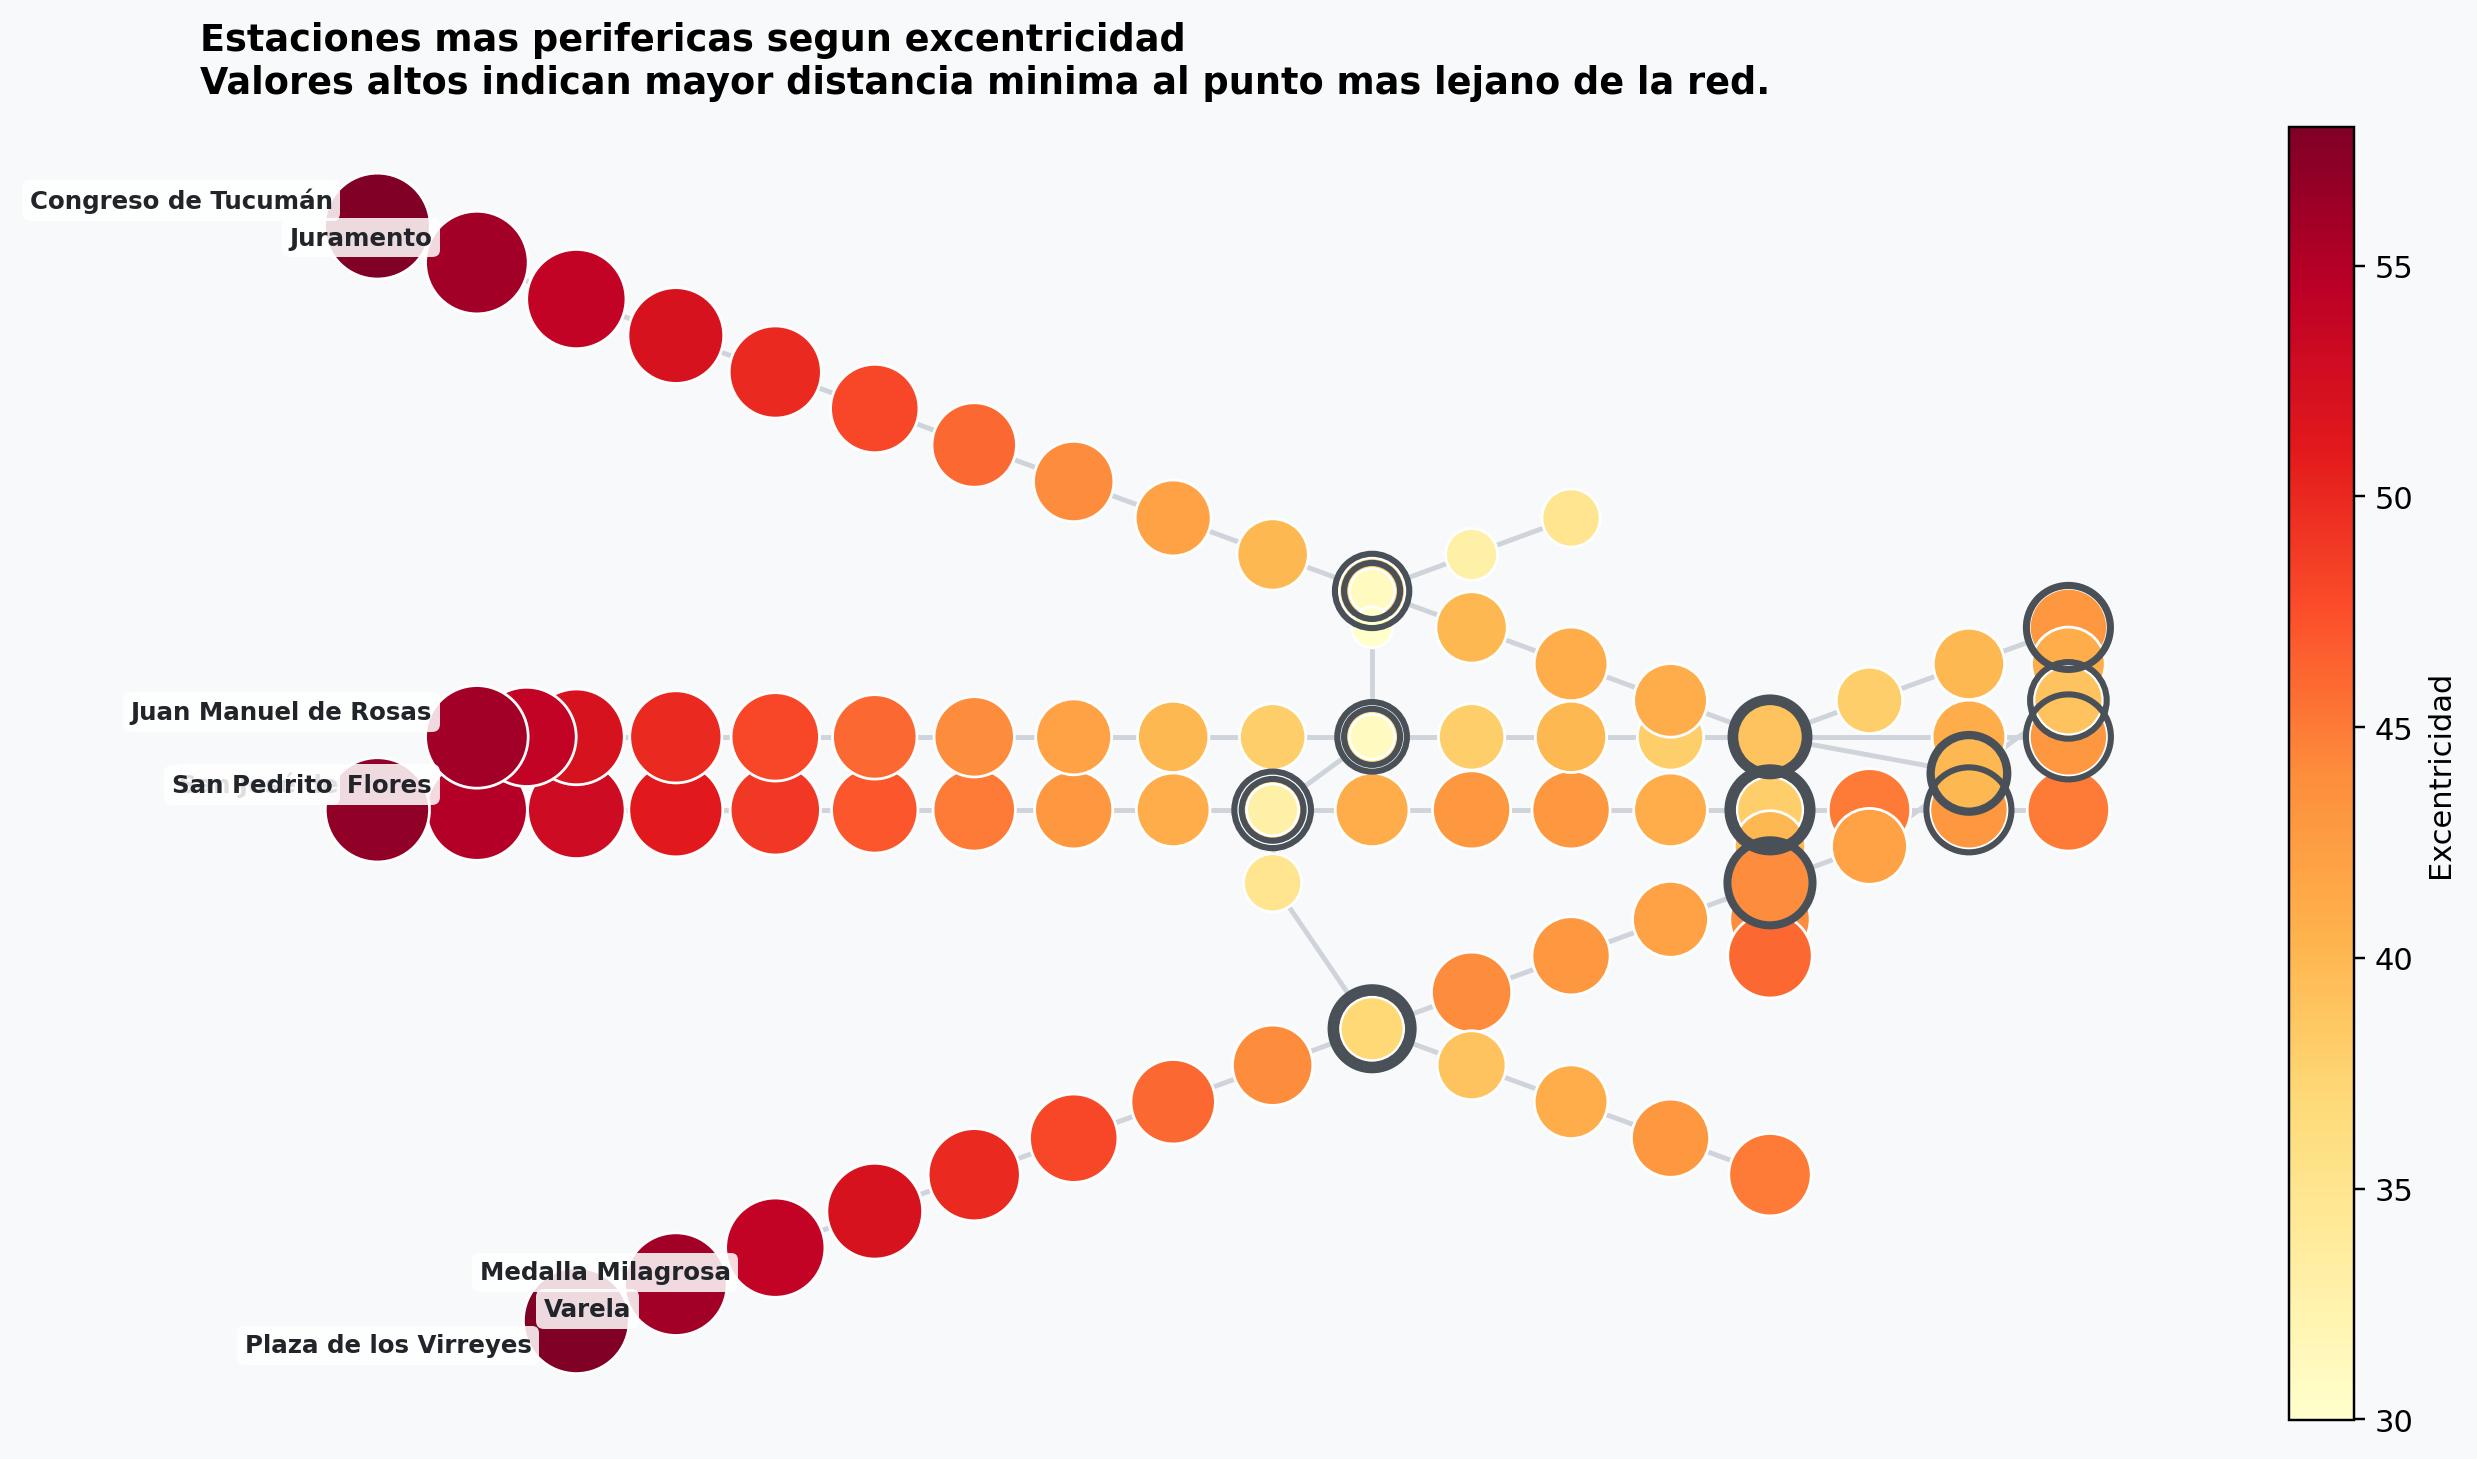

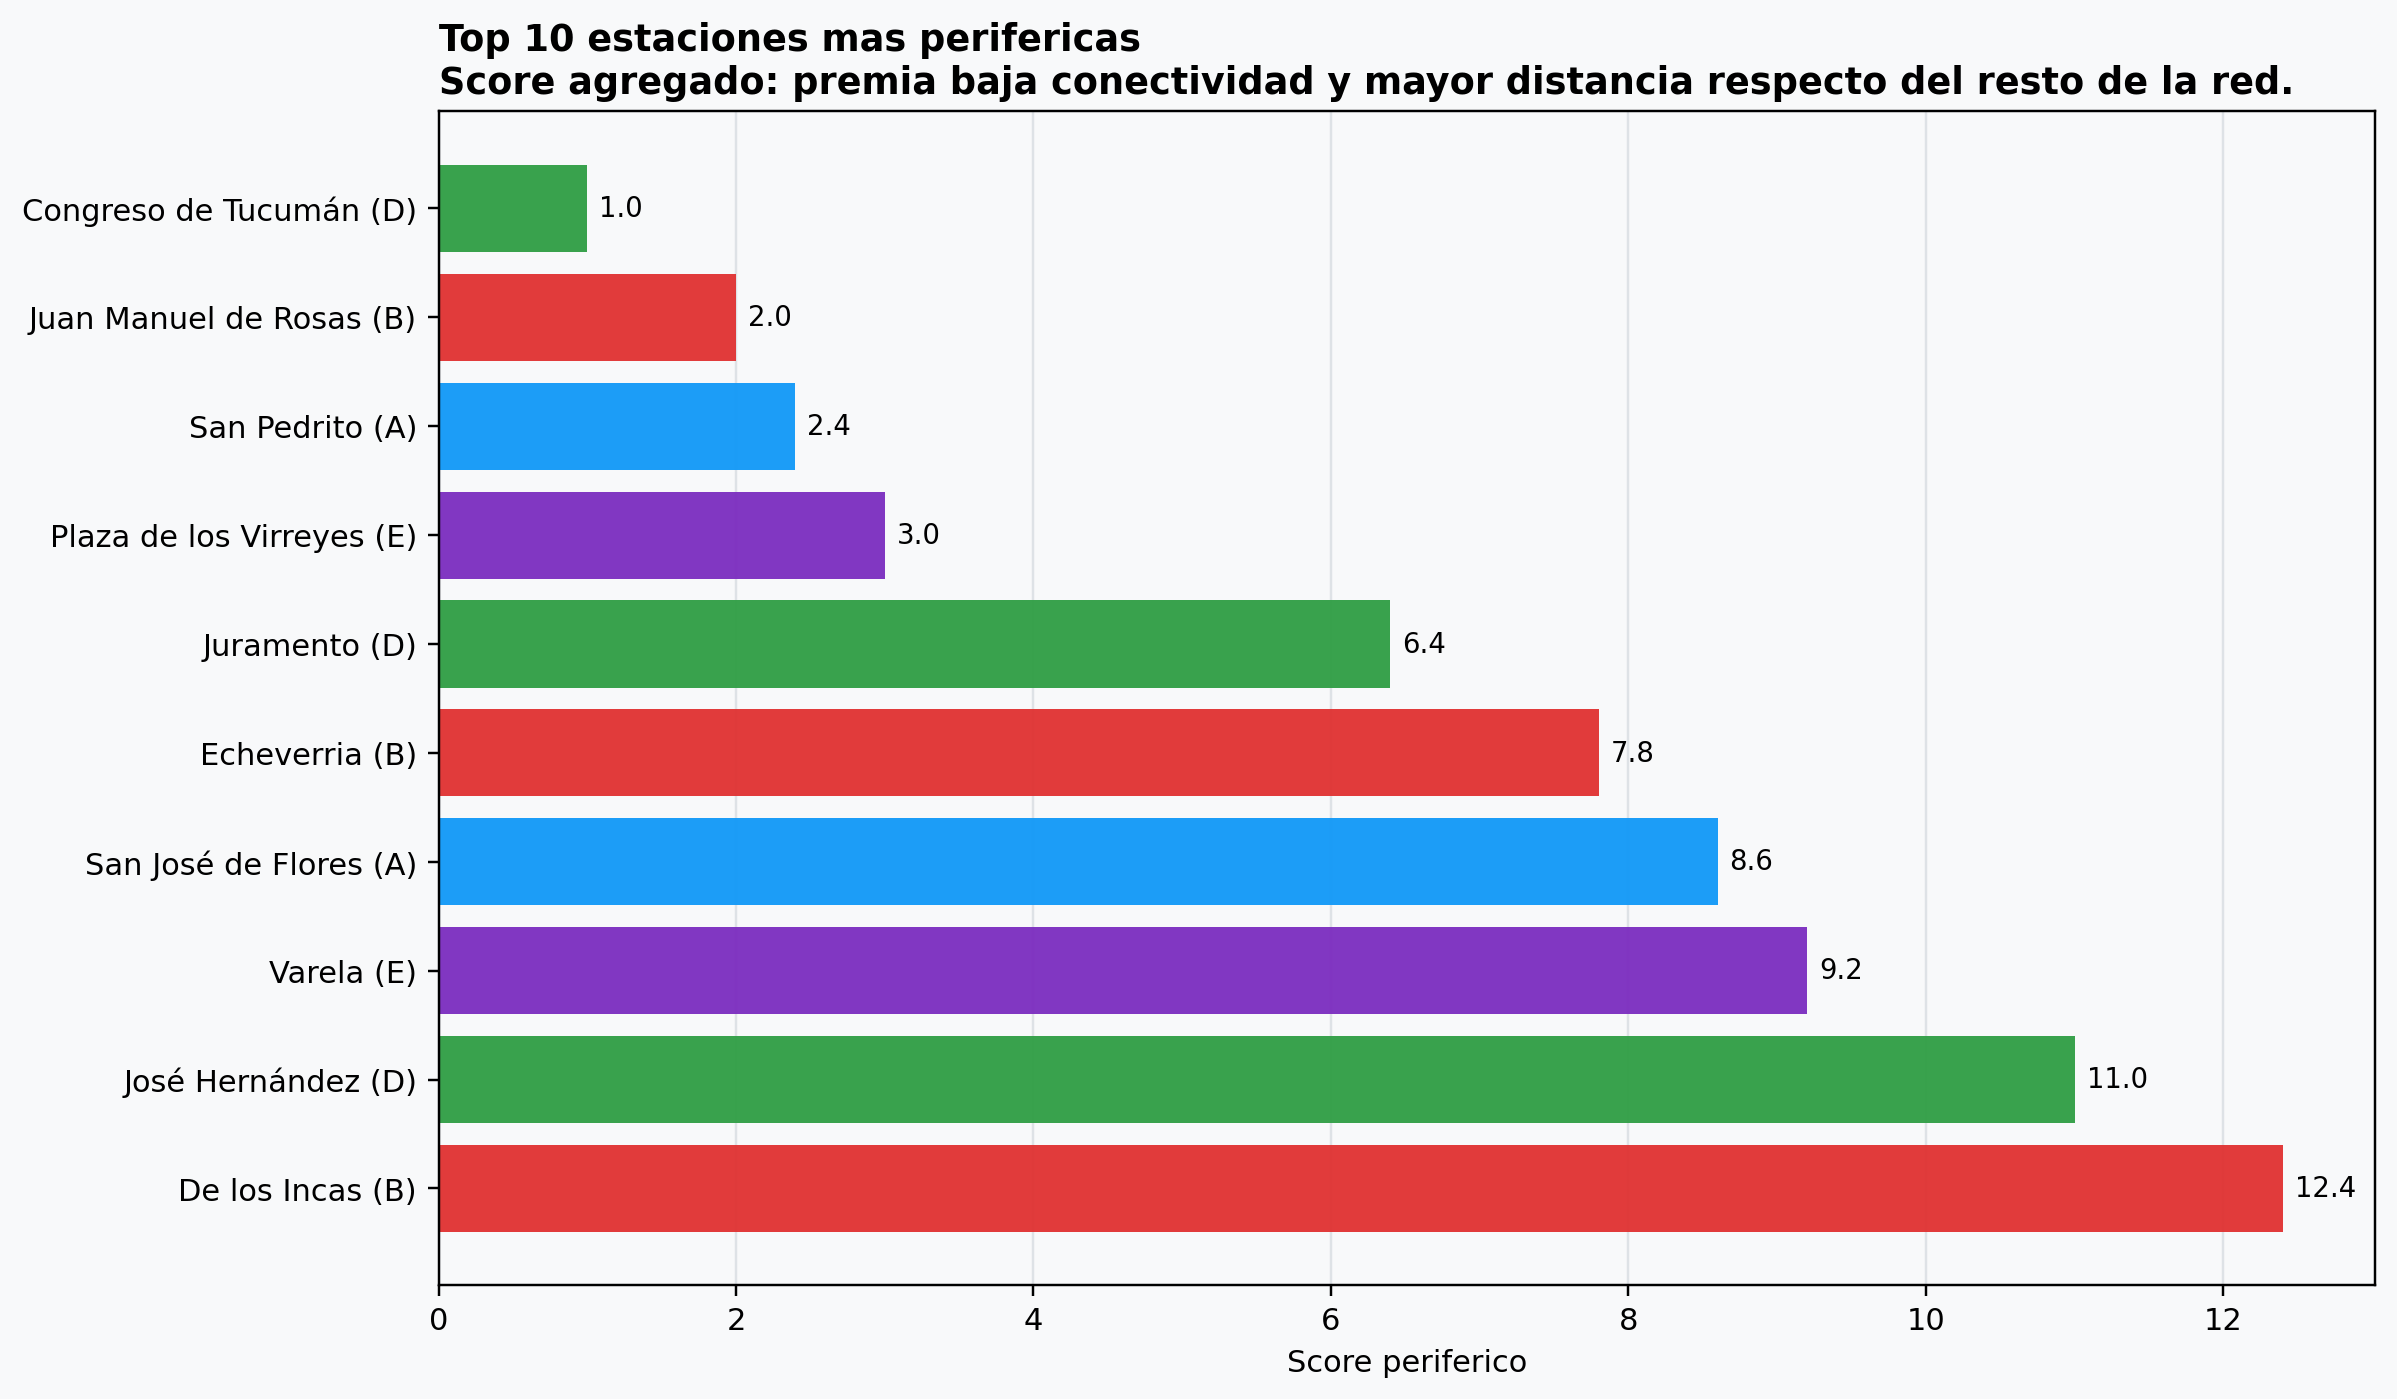

,estacion,linea,grado,betweenness,closeness,autovector,excentricidad,score_central,score_periferico
59,Congreso de Tucumán,D,1.0,0.000000,0.026671,0.000710,58,87.0,1.0
34,Juan Manuel de Rosas,B,1.0,0.000000,0.027640,0.000731,56,85.8,2.0
17,San Pedrito,A,1.0,0.000000,0.028562,0.000916,57,85.8,2.4
74,Plaza de los Virreyes,E,1.0,0.000000,0.029441,0.001645,58,85.0,3.0
58,Juramento,D,2.0,0.022472,0.028156,0.001530,56,70.6,6.4
33,Echeverria,B,2.0,0.022472,0.029238,0.001575,54,69.2,7.8
16,San José de Flores,A,2.0,0.022472,0.030272,0.001974,55,68.8,8.6
73,Varela,E,2.0,0.022472,0.031261,0.003545,56,67.8,9.2
57,José Hernández,D,2.0,0.044433,0.029776,0.002588,54,66.4,11.0
32,De los Incas,B,2.0,0.044433,0.030989,0.002664,52,65.0,12.4


In [6]:
display(Image(filename=str(FIGURES_DIR / 'centralidad_estaciones_por_excentricidad.png')))
display(Image(filename=str(FIGURES_DIR / 'ranking_estaciones_perifericas.png')))
top_peripheral

Interpretacion:

- Las cabeceras de las lineas A, B, D y E dominan la periferia.
- **Congreso de Tucuman**, **San Pedrito** y **Plaza de los Virreyes** son casos claros: tienen pocas alternativas cercanas y quedan lejos de los principales nodos de intercambio.
- Este patron es esperable en una red radial con la mayor densidad de conexiones concentrada hacia el centro.

## 5. Resumen por linea

Como complemento, este grafico resume el tamano de cada linea y cuantas estaciones de cada una participan en transbordos.

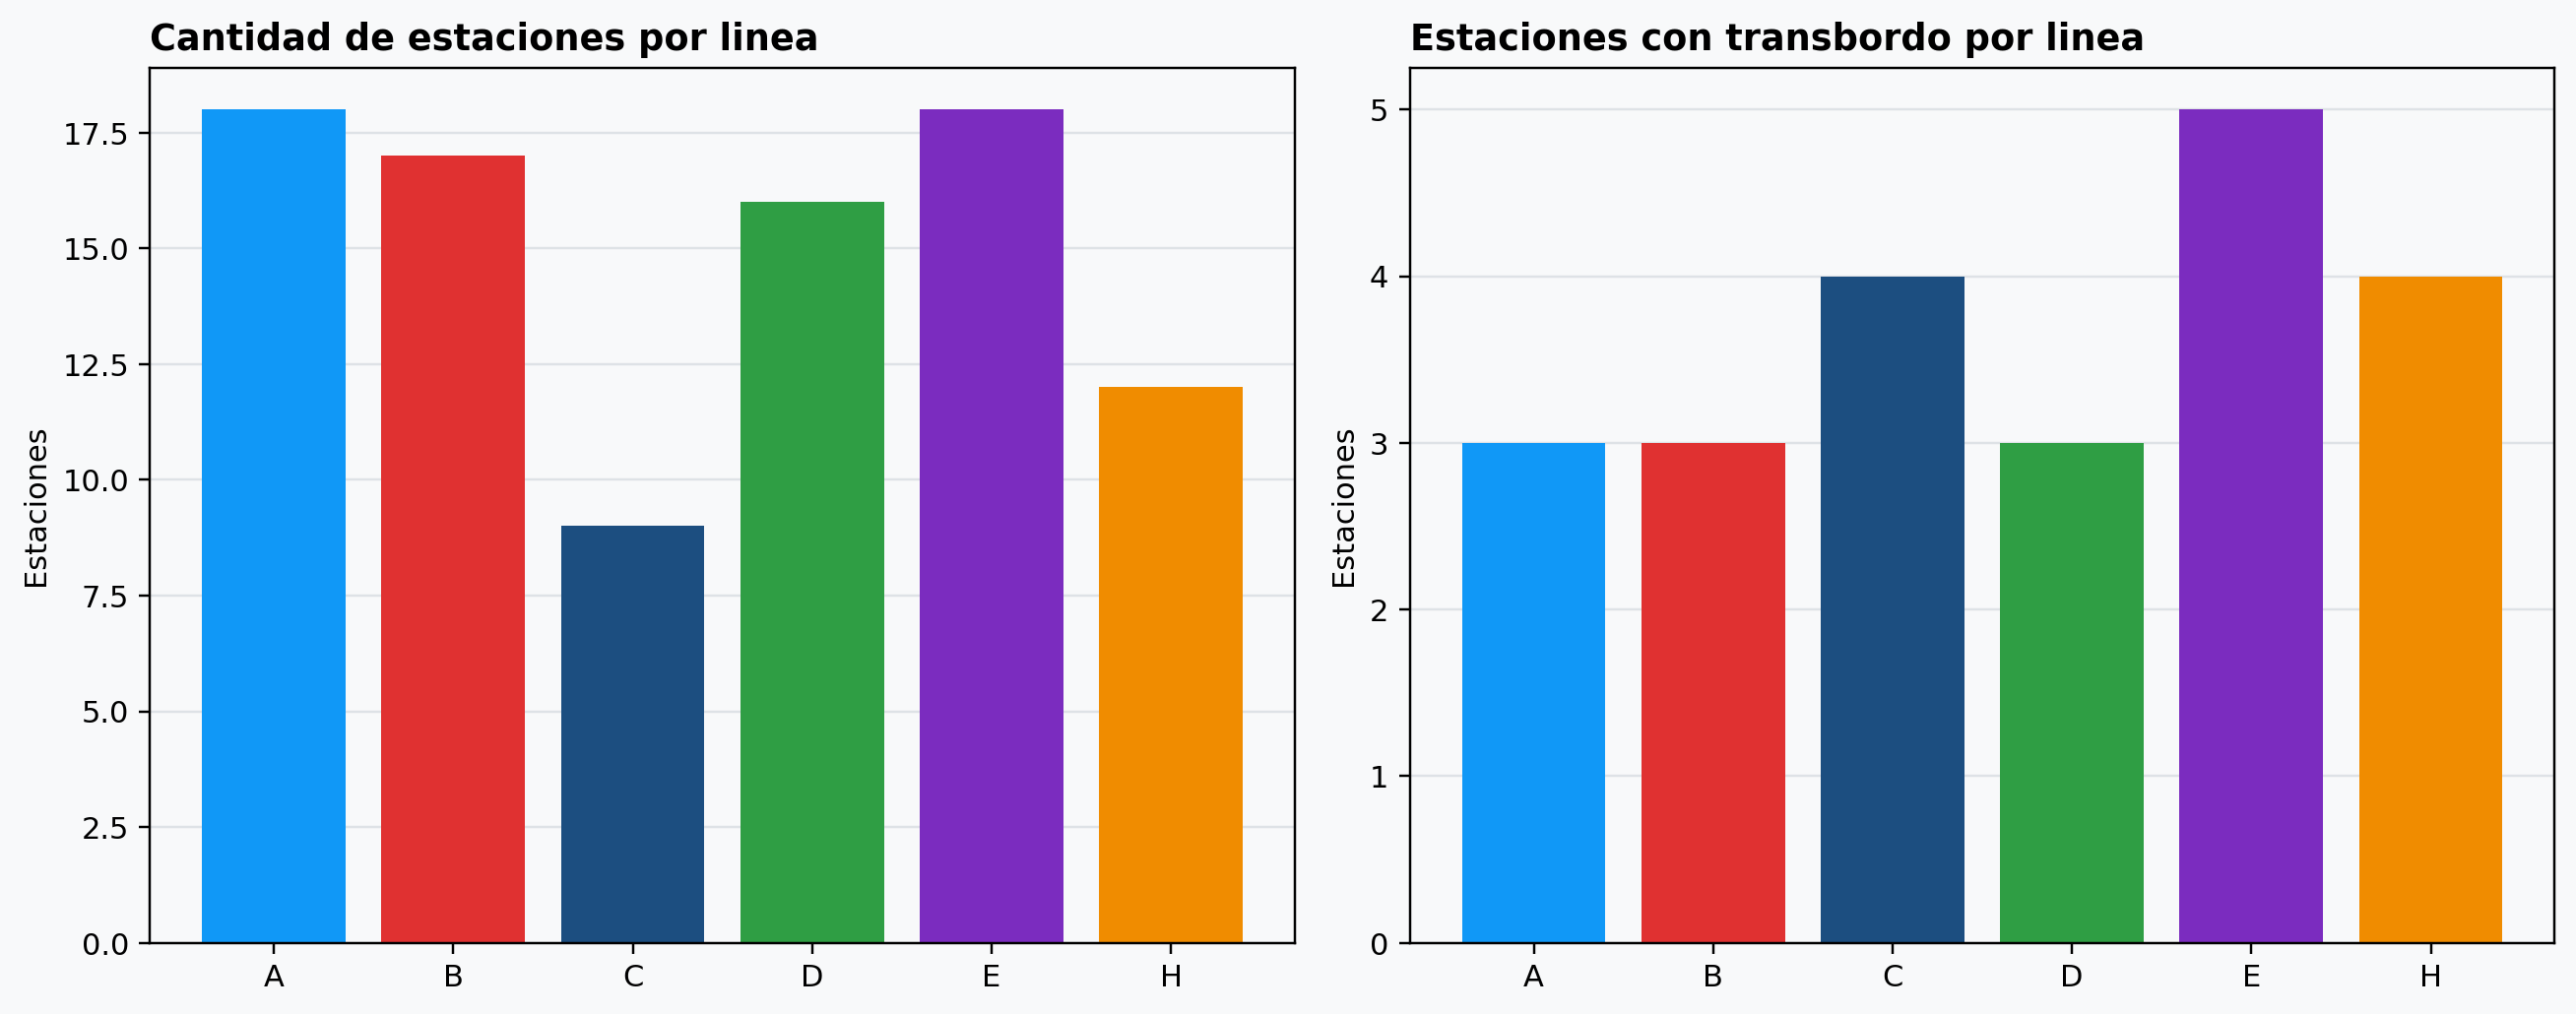

,linea,estaciones,estaciones_con_transbordo,cabeceras
0,A,18,3,2
1,B,17,3,2
2,C,9,4,2
3,D,16,3,2
4,E,18,5,2
5,H,12,4,2


In [7]:
display(Image(filename=str(FIGURES_DIR / 'resumen_por_linea.png')))
line_summary

## 6. Escenario futuro con las lineas F, G e I

Para recuperar el analisis de las estaciones nuevas, se modela un escenario que agrega la linea F oficial 2025 y las primeras etapas historicas de G e I. Esta seccion usa el mismo pipeline que genera la figura `red_subte_caba_futuro_esquematico.png` y las tablas exportadas en `outputs/`.

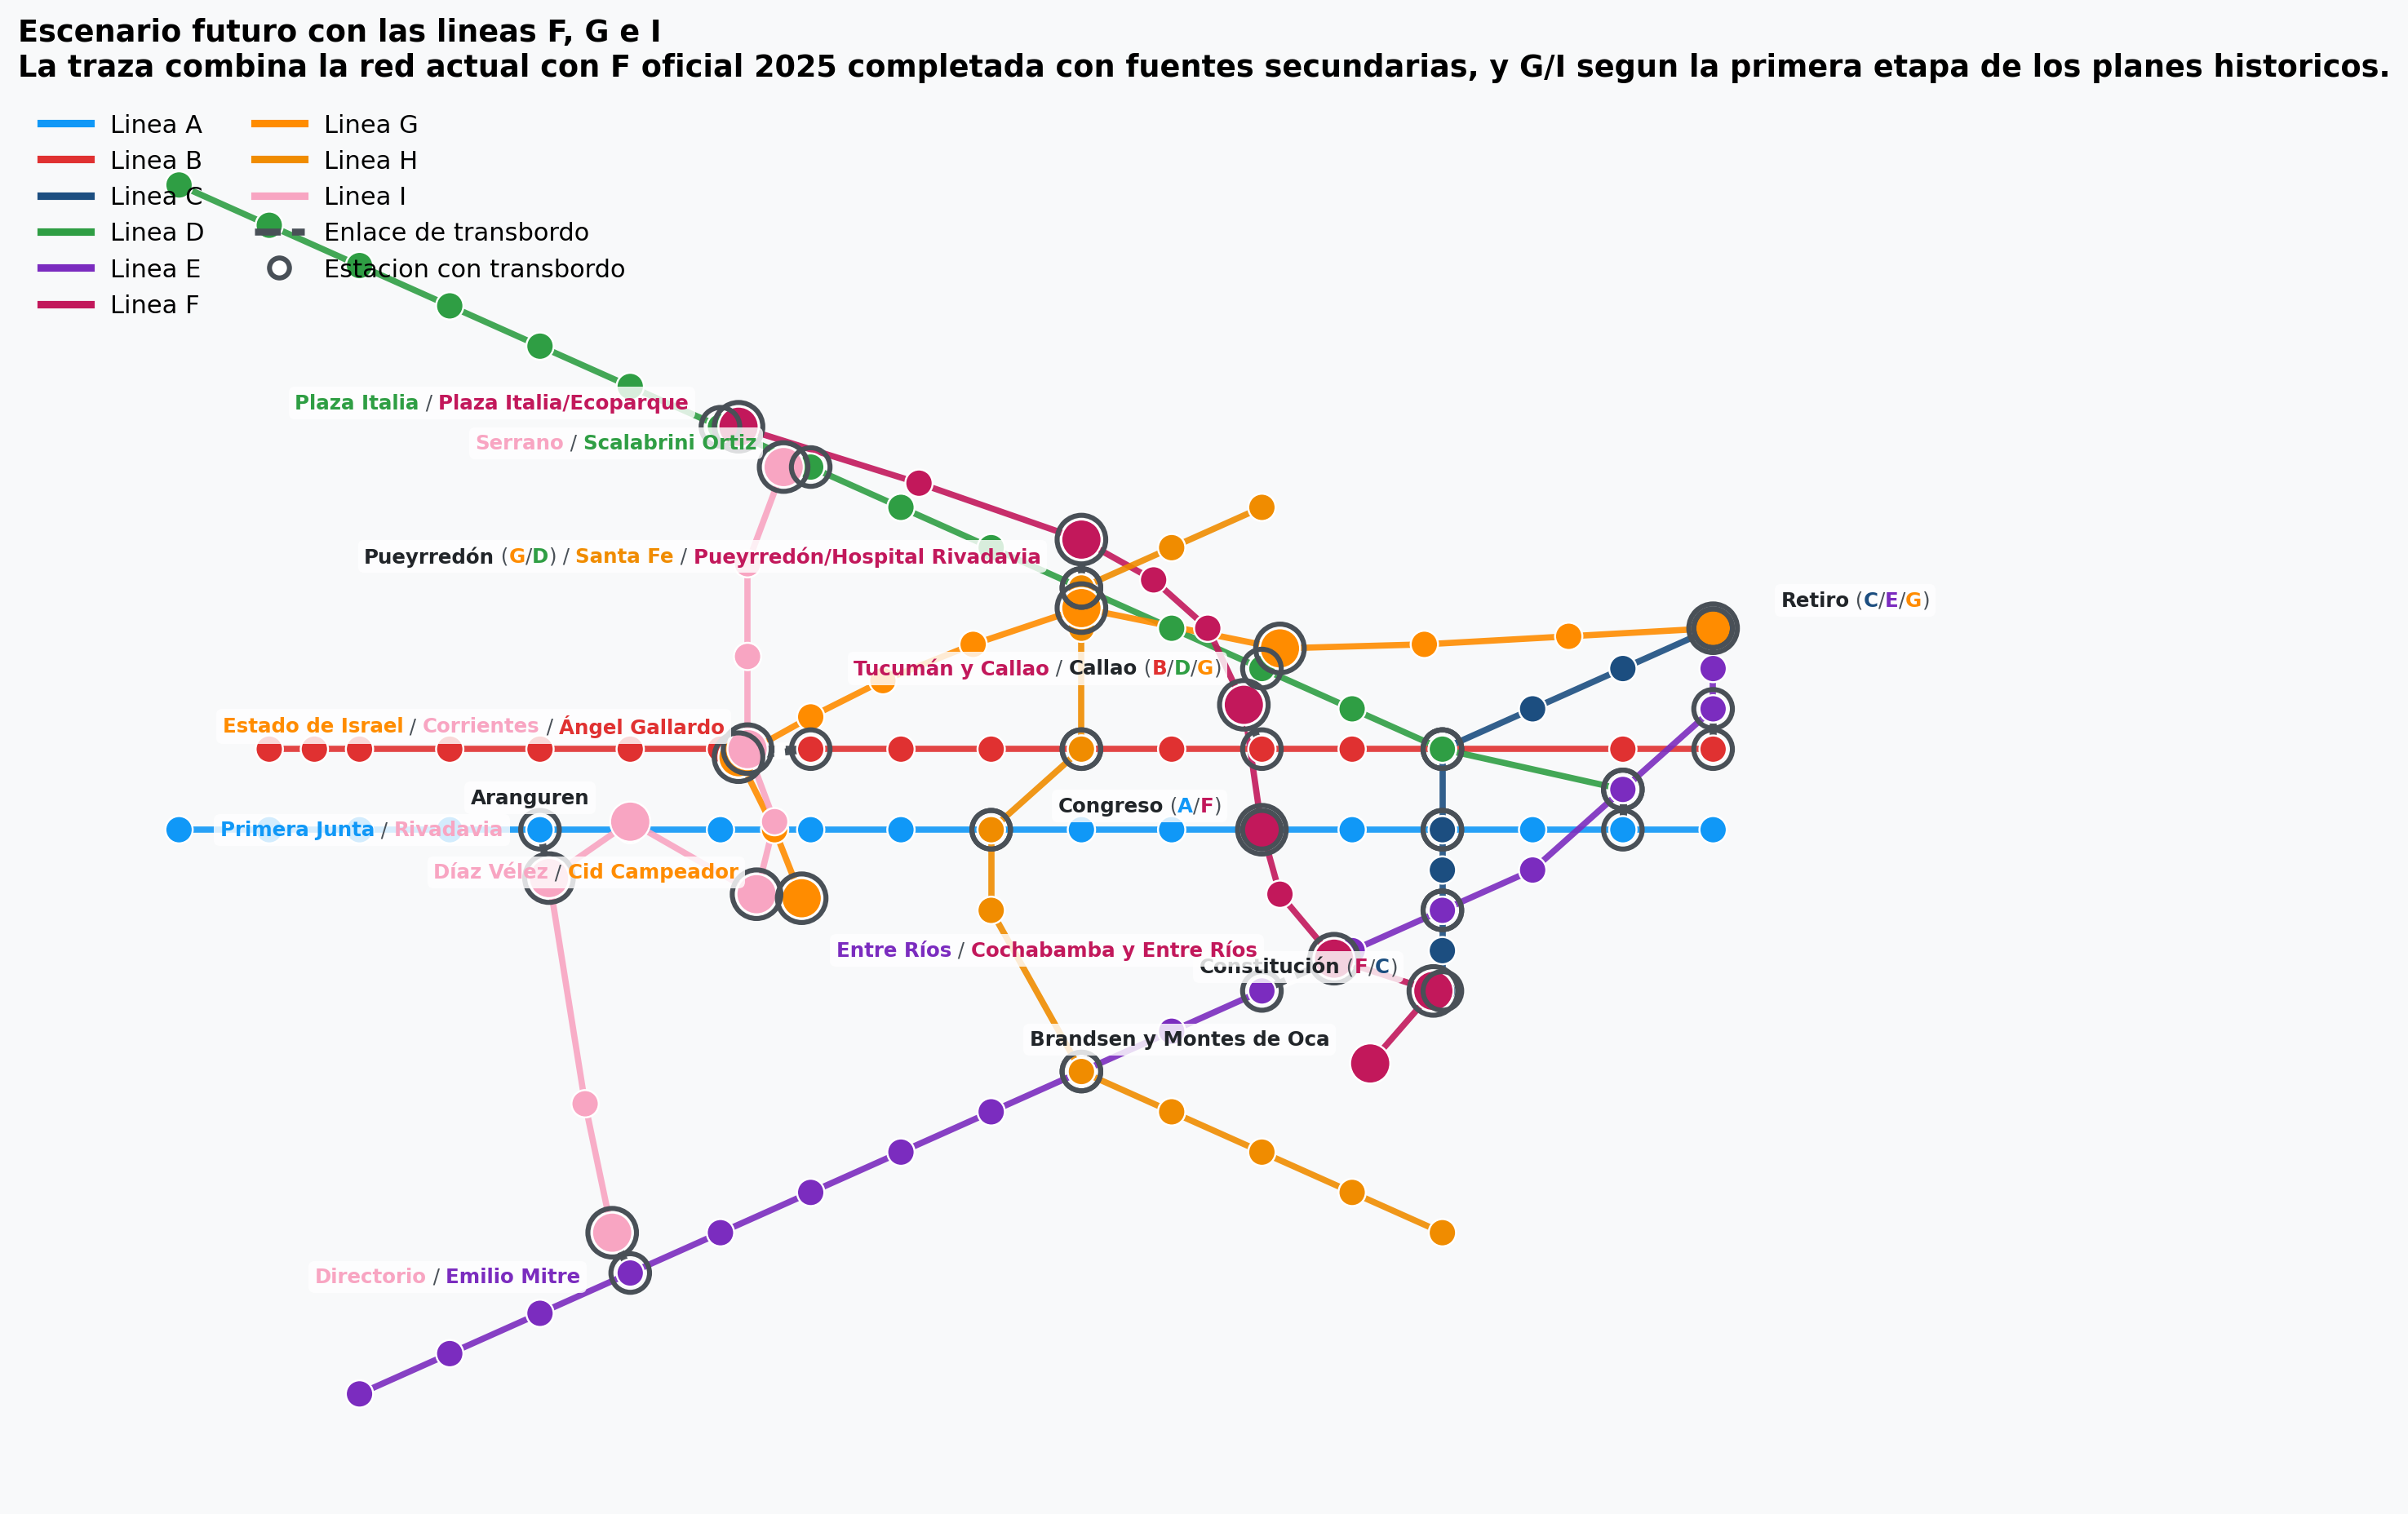

,escenario,estaciones_nuevas,transbordos_nuevos,tiempo_medio,mejora_tiempo_pct,eficiencia,mejora_eficiencia_pct,diametro,radio,caida_betweenness_hubs_pct,betweenness_nuevas_estaciones
0,F,11,7,23.22,1.22,0.07,0.74,58.0,29,10.51,0.51
1,G,11,5,23.38,0.56,0.06,0.23,58.0,30,2.95,0.24
2,I,10,4,22.66,3.63,0.07,1.24,49.0,30,24.76,0.65
3,F+G+I,32,18,22.31,5.12,0.07,2.12,49.0,29,33.78,1.20


In [8]:
display(Image(filename=str(FIGURES_DIR / 'red_subte_caba_futuro_esquematico.png')))

future_scenarios = future['scenario_table'].copy()
for column in [
    'tiempo_medio',
    'mejora_tiempo_pct',
    'eficiencia',
    'mejora_eficiencia_pct',
    'caida_betweenness_hubs_pct',
    'betweenness_nuevas_estaciones',
]:
    future_scenarios[column] = future_scenarios[column].round(2)

future_scenarios

Lectura rapida:

- La combinacion `F+G+I` es la que mas mejora la red: baja el tiempo medio entre estaciones actuales en torno a 5.1% y reduce 33.4% la betweenness acumulada de los hubs actuales.
- Entre las lineas evaluadas por separado, la I es la mas potente: recorta el tiempo medio 3.55% y descarga 24.3% del flujo de los nodos mas exigidos.
- La F agrega nuevos puntos de intercambio fuertes en el corredor central, mientras que la G suma conectividad lateral pero con un efecto mas acotado en esta primera etapa.

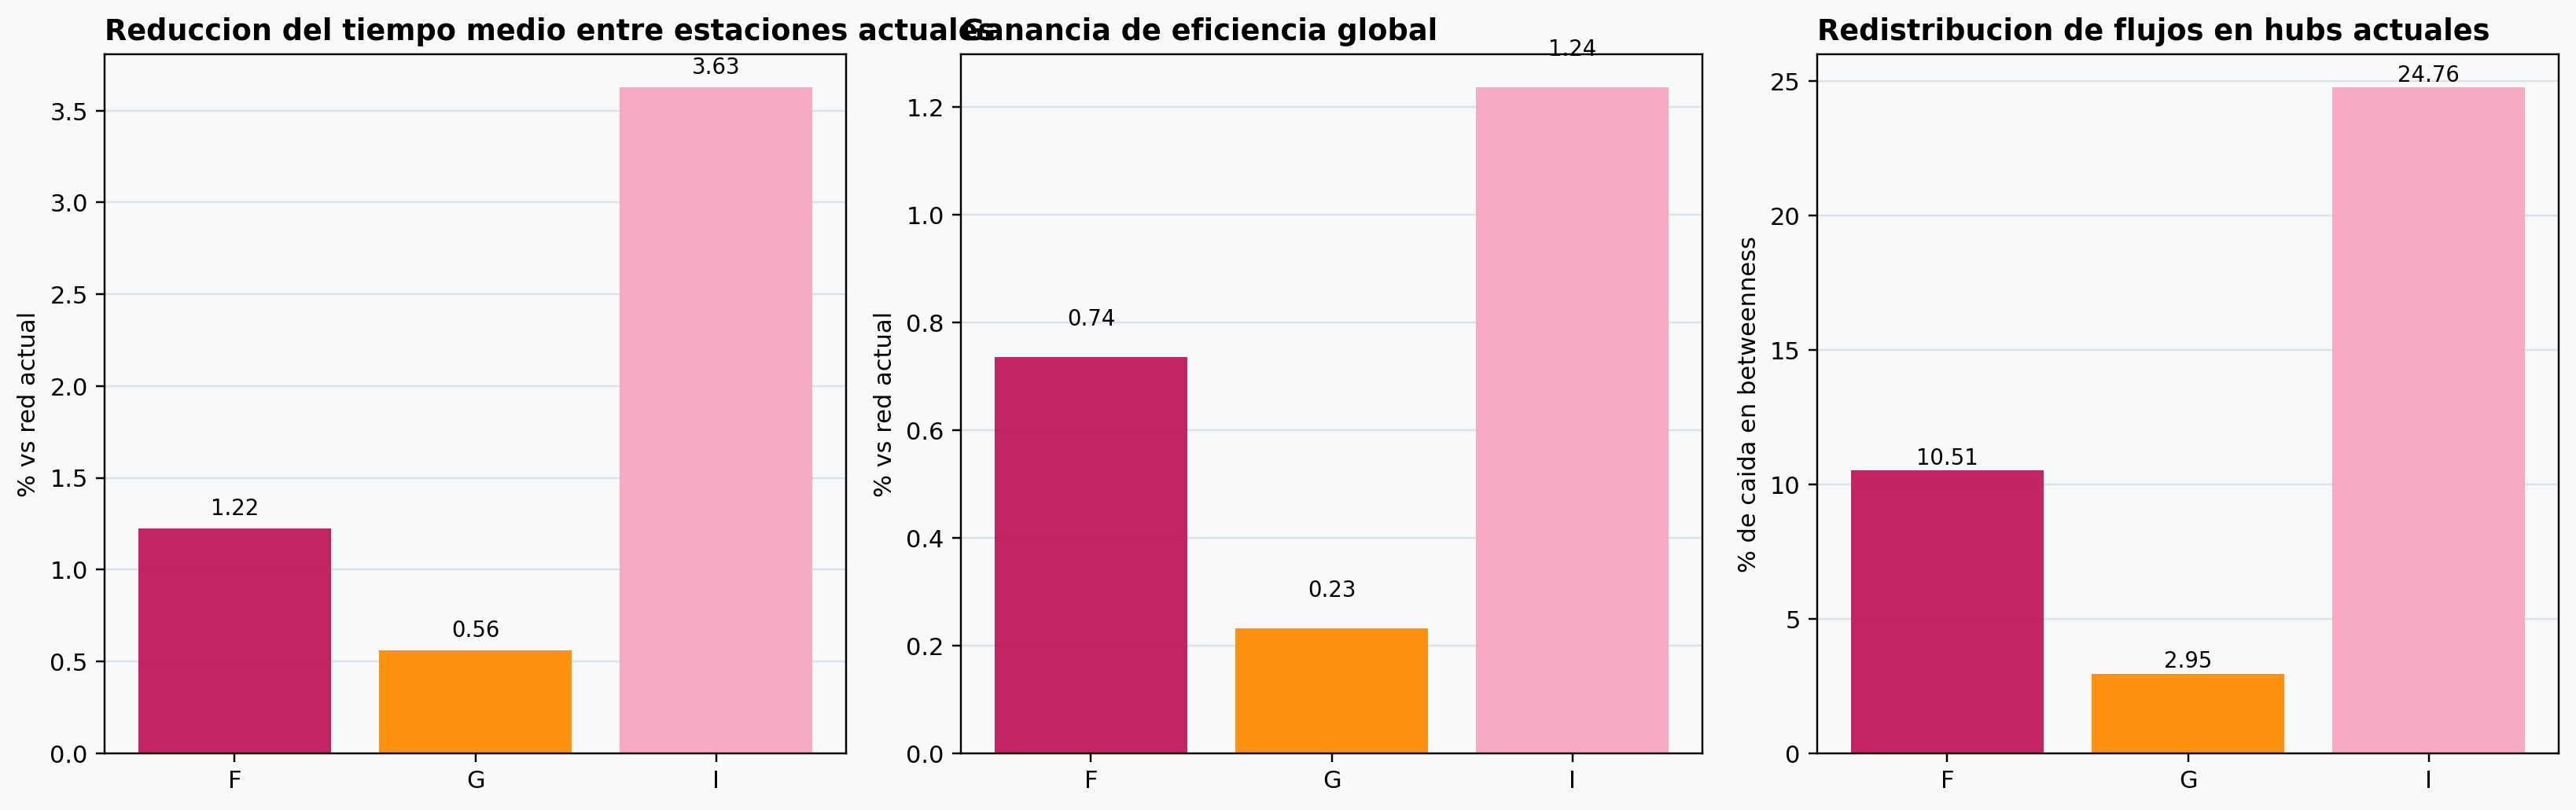

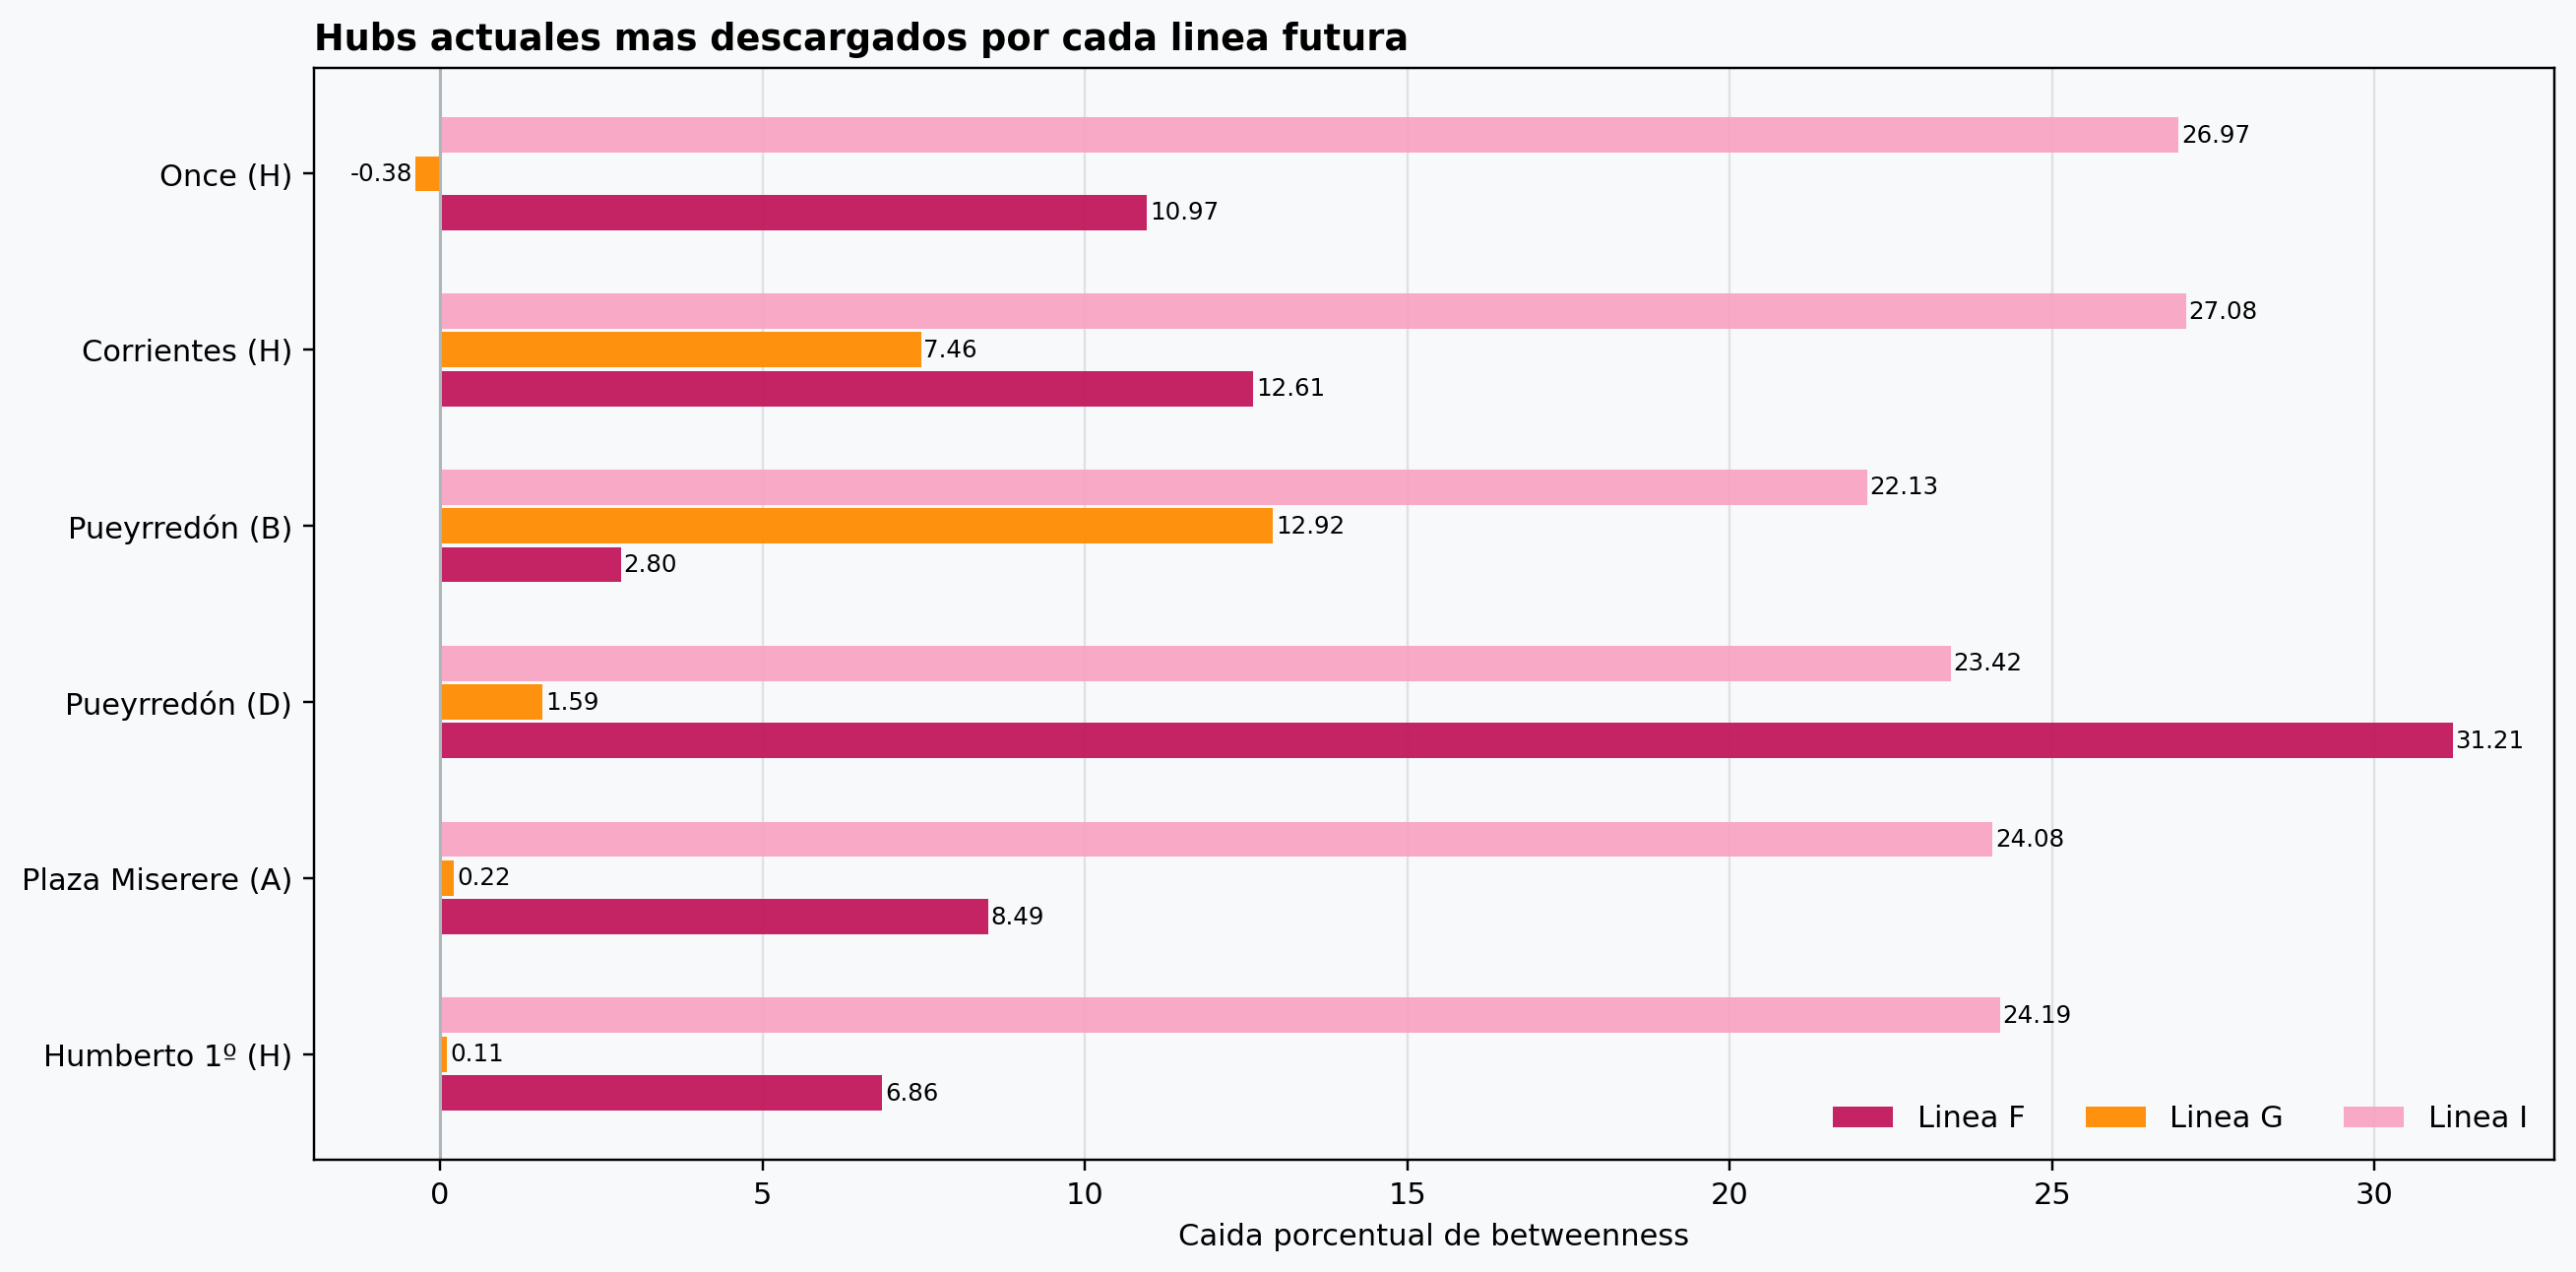

,criterio,ganadora_entre_F_G_I
0,reduccion de distancias entre estaciones actuales,I
1,redistribucion de flujos en hubs actuales,I


In [9]:
display(Image(filename=str(FIGURES_DIR / 'comparacion_lineas_futuras.png')))
display(Image(filename=str(FIGURES_DIR / 'alivio_hubs_futuros.png')))

pd.DataFrame(
    [
        {
            'criterio': 'reduccion de distancias entre estaciones actuales',
            'ganadora_entre_F_G_I': future['winners']['distance'],
        },
        {
            'criterio': 'redistribucion de flujos en hubs actuales',
            'ganadora_entre_F_G_I': future['winners']['redistribution'],
        },
    ]
)

Las nuevas estaciones con mayor centralidad quedan concentradas sobre los corredores I y F. En particular, `Rivadavia` (I) lidera la betweenness sobre demanda actual, mientras que `Tucuman y Callao` (F) aparece como el nodo mas fuerte cuando se combina intermediacion con cercania.

In [10]:
future_line_centrality = future['line_centrality'].copy()
for column in [
    'betweenness_demanda_actual_total',
    'betweenness_demanda_actual_media',
    'closeness_media',
]:
    future_line_centrality[column] = future_line_centrality[column].round(4)

future_line_centrality

,linea,estaciones_modeladas,betweenness_demanda_actual_total,betweenness_demanda_actual_media,closeness_media,top_estacion_betweenness,top_estacion_closeness
2,I,10,0.6397,0.064,0.0447,Rivadavia,Corrientes
0,F,11,0.4179,0.038,0.0532,Tucumán y Callao,Tucumán y Callao
1,G,11,0.1433,0.013,0.0516,Pueyrredón,Pueyrredón


In [11]:
top_future = future['top_future_stations'].copy()
for column in ['betweenness_demanda_actual', 'betweenness', 'closeness', 'score_central']:
    top_future[column] = top_future[column].round(4)

top_future

,estacion,linea,betweenness_demanda_actual,betweenness,closeness,score_central
114,Rivadavia,I,0.0896,0.1145,0.0446,46.6
118,Corrientes,I,0.0861,0.1074,0.0469,40.6
95,Tucumán y Callao,F,0.0824,0.1638,0.0613,1.2
94,Congreso,F,0.0760,0.1377,0.0602,6.4
117,Warnes,I,0.0633,0.0767,0.0458,59.0
116,Díaz Vélez,I,0.0633,0.1031,0.0457,49.2
115,Aranguren,I,0.0633,0.0953,0.0449,58.2
113,Pedro Goyena,I,0.0554,0.0635,0.0428,70.8
112,Directorio,I,0.0554,0.0585,0.0416,74.8
119,Córdoba,I,0.0544,0.0634,0.0449,63.2


## 7. Conclusion

La red actual muestra una estructura claramente centralizada: los principales transbordos y las estaciones mas estrategicas se concentran en el corredor central, mientras que las cabeceras aparecen como nodos perifericos.

En el escenario futuro, la ampliacion con F, G e I mantiene esa logica pero reparte mejor los recorridos, sobre todo cuando se incorpora la linea I y, con mas fuerza aun, la combinacion completa de los tres proyectos. Desde el punto de vista de la conectividad, la linea H sigue siendo un conector transversal clave en la red actual, mientras que F e I aparecen como las expansiones con mayor capacidad para aliviar hubs existentes y abrir alternativas fuera del microcentro.